# Model audit — Cordilla Systems account scoring

**What this notebook is.** An audit of `model/model.pkl`, a scoring model found unused in
the Salesforce environment. Nobody flagged it, so nobody is vouching for it. The question
is not "how good is it" but **"does it deserve to be trusted, and with what."**

**What it is not.** It does not retrain, tune, or replace the shipped model. Section 0.4
establishes exactly one exception and why it is not retraining.

**Reference date is 2026-08-01**, not the system clock. Both CSVs are static snapshots
taken that day.

---

### Contents

| § | | one-line finding |
|---|---|---|
| **0** | Integrity and provenance | The pickle was fit on all 1200 labeled rows, in file order, with no holdout — proven bit-for-bit |
| **1** | What is in the box | 40 stumps of depth 2; median imputation on the one column that has gaps |
| **2** | Reported vs. real performance | **The headline AUC of 0.759 is what this architecture produces from random labels** |
| **3** | Every variable, one at a time | Importance tracks cardinality, not signal; `intent_score` contributes only its missingness |
| **4** | Stability and robustness | Half the call list is an artifact of the random seed; a null `account_type` crashes scoring |
| **5** | Allocation impact | Rep hours are split 5.6× across industries on the basis of no measured difference |
| **6** | Consolidated verdict | What to trust, what not to, what not to ship |

In [1]:
import warnings, pickle, hashlib, itertools
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, log_loss
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 60, "display.float_format", lambda v: f"{v:,.4f}")

TODAY    = pd.Timestamp("2026-08-01")     # the packet's "today", not the system clock
FEATURES = ["account_type", "employee_count", "industry", "intent_score", "mql_count_90d",
            "trial_started", "trial_active_users", "web_touchpoints_90d", "sales_contacts_90d"]
CAT      = ["account_type", "industry"]
NUM      = [f for f in FEATURES if f not in CAT]
TARGET   = "converted_within_90d"

# one house style for every figure in the notebook
mpl.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": .25, "grid.linewidth": .6,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 9,
                     "legend.frameon": False})
INK, WARN, GOOD, MUTE = "#1f3a5f", "#c2402a", "#2f7d54", "#9aa5b1"

def show(df, title=None, n=None):
    if title: print(f"\n{title}\n" + "-" * len(title))
    print((df.head(n) if n else df).to_string())

In [2]:
train = pd.read_csv("../data/training_data.csv", parse_dates=["snapshot_date"])
score = pd.read_csv("../data/accounts_to_score.csv", parse_dates=["snapshot_date"])
with open("../model/model.pkl", "rb") as f:
    model = pickle.load(f)

X,  y  = train[FEATURES], train[TARGET].to_numpy()
Xs     = score[FEATURES]
BASE   = y.mean()

for name, df in [("training", train), ("scoring", score)]:
    print(f"{name:9s} {df.shape[0]:5,d} rows x {df.shape[1]:2d} cols   "
          f"snapshots {df.snapshot_date.min():%Y-%m-%d} .. {df.snapshot_date.max():%Y-%m-%d}")
print(f"\npositives {y.sum()} / {len(y)}  =  base rate {BASE:.4%}")
print(f"model.pkl sha256 {hashlib.sha256(open('../model/model.pkl','rb').read()).hexdigest()[:16]}")

training  1,200 rows x 12 cols   snapshots 2024-08-20 .. 2026-07-31
scoring     300 rows x 11 cols   snapshots 2024-09-25 .. 2026-08-01

positives 78 / 1200  =  base rate 6.5000%
model.pkl sha256 fc2cd6aa4400c6bc


## 0. Integrity and provenance

Before any metric, two questions. Are the files internally sound? And — the one nobody
asks — **what exactly was this model fit on?** Everything in §2 depends on the answer.

### 0.1 Integrity checks

Negative results are findings too. Reporting what an audit *did not* find is what stops
the next reader from re-running it.

In [3]:
checks = []
def chk(name, ok, detail=""):
    checks.append({"check": name, "result": "pass" if ok else "FLAG", "detail": detail})

both = pd.concat([train.assign(_src="train"), score.assign(_src="score")], ignore_index=True)

chk("no duplicate account_id within either file",
    train.account_id.is_unique and score.account_id.is_unique)
overlap = set(train.account_id) & set(score.account_id)
chk("no train/score account overlap", not overlap, f"{len(overlap)} shared ids")
chk("no snapshot_date after 2026-08-01", both.snapshot_date.max() <= TODAY,
    f"max {both.snapshot_date.max():%Y-%m-%d}")
chk("employee_count strictly positive", (both.employee_count > 0).all(),
    f"range {both.employee_count.min()}-{both.employee_count.max():,}")
chk("trial_active_users never exceeds employee_count",
    (both.trial_active_users <= both.employee_count).all())
chk("trial_active_users == 0 whenever trial_started == 0",
    (both.loc[both.trial_started == 0, "trial_active_users"] == 0).all())
chk("no negative counts", (both[["mql_count_90d","trial_active_users",
                                 "web_touchpoints_90d","sales_contacts_90d"]] >= 0).all().all())
chk("target is strictly binary", set(train[TARGET].unique()) == {0, 1})
chk("identical column schema apart from the target",
    list(score.columns) == [c for c in train.columns if c != TARGET])

nulls = both[FEATURES].isna().sum()
chk("intent_score is the ONLY column with missing values", (nulls.drop("intent_score") == 0).all(),
    f"intent_score {nulls.intent_score} missing "
    f"({train.intent_score.isna().sum()} train / {score.intent_score.isna().sum()} score)")
chk("categorical levels in scoring all seen in training",
    all(set(score[c]) <= set(train[c]) for c in CAT))

show(pd.DataFrame(checks), "Integrity")


Integrity
---------
                                                  check result                                            detail
0            no duplicate account_id within either file   pass                                                  
1                        no train/score account overlap   pass                                      0 shared ids
2                     no snapshot_date after 2026-08-01   pass                                    max 2026-08-01
3                      employee_count strictly positive   pass                                     range 3-4,429
4       trial_active_users never exceeds employee_count   pass                                                  
5   trial_active_users == 0 whenever trial_started == 0   pass                                                  
6                                    no negative counts   pass                                                  
7                             target is strictly binary   pass             

Nothing broken, and that is worth stating plainly: no duplicates, no leakage between the
files by id, no impossible values, no future snapshots, no nulls anywhere except
`intent_score`.

The single structural gap is `intent_score` — missing on ~40% of rows in both files,
which matches the packet's description of partial vendor coverage. §3.4 is about what
that gap does.

### 0.2 Forensics on the account ids

A cheap check that turns out to matter for §3.11.

In [4]:
ids = np.sort(both.account_id.str.slice(4).astype(int).to_numpy())
print(f"account_id numeric range {ids.min()}..{ids.max()}   n={len(ids)}   "
      f"gaps={len(set(range(ids.min(), ids.max()+1)) - set(ids))}")

# does the id itself carry label information? (it would, if the file were sorted by outcome)
tid = train.account_id.str.slice(4).astype(int)
r, p = st.pearsonr(tid, y)
print(f"corr(account_id, target) = {r:+.4f}  p = {p:.3f}")

# is the train/score split random, or stratified on something?
both["age_days"] = (TODAY - both.snapshot_date).dt.days
bands = pd.cut(both.age_days, [-1, 90, 180, 365, 10_000],
               labels=["<=90d", "90-180d", "180-365d", ">365d"])
tab = pd.crosstab(bands, both._src)
tab["P(row is in scoring file)"] = tab["score"] / tab.sum(axis=1)
show(tab, "Where each age band landed")

account_id numeric range 1..1500   n=1500   gaps=0
corr(account_id, target) = +0.0133  p = 0.646

Where each age band landed
--------------------------
_src      score  train  P(row is in scoring file)
age_days                                         
<=90d        82    103                     0.4432
90-180d     116    220                     0.3452
180-365d     60    484                     0.1103
>365d        42    393                     0.0966


**Two things.**

The ids run `1…1500` with **no gaps and no overlap** — one generated population split into
1200 + 300. These are synthetic files, which is expected for an exercise, and the id
carries no label information (p ≈ 0.65), so it is not a leak.

But the split is **not random**. A row's chance of landing in the scoring file falls from
~44% for fresh snapshots to ~10% for snapshots over a year old. That is deliberate
recency-biased sampling. It matters in §3.11, where the naive read of the same fact is
"the population has drifted" — a claim the panel can disprove by opening the CSVs.

### 0.3 Class balance and the number that governs the whole audit

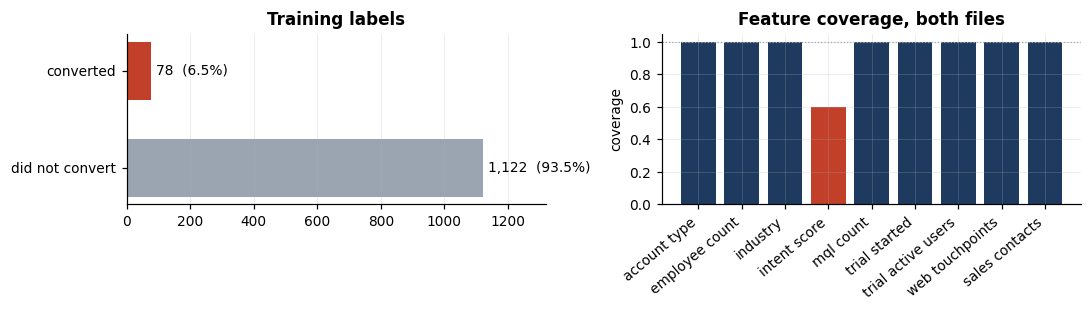

78 positives is the budget for this entire audit. Every subgroup claim below is a
partition of 78 events across 9 features. A cell with 10 accounts in it
carries roughly 0.7 expected conversions, so it can say almost nothing.


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2.9))
ax[0].barh(["did not convert", "converted"], [(y==0).sum(), y.sum()], color=[MUTE, WARN], height=.6)
for i, v in enumerate([(y==0).sum(), y.sum()]):
    ax[0].text(v + 14, i, f"{v:,}  ({v/len(y):.1%})", va="center", fontsize=9)
ax[0].set_xlim(0, 1320); ax[0].set_title("Training labels"); ax[0].grid(axis="y", visible=False)

ax[1].bar(range(len(FEATURES)), [1 - both[f].isna().mean() for f in FEATURES],
          color=[WARN if f == "intent_score" else INK for f in FEATURES])
ax[1].set_xticks(range(len(FEATURES)))
ax[1].set_xticklabels([f.replace("_90d","").replace("_"," ") for f in FEATURES], rotation=40, ha="right")
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("coverage"); ax[1].set_title("Feature coverage, both files")
ax[1].axhline(1, color=MUTE, lw=.8, ls=":")
plt.tight_layout(); plt.show()

print(f"78 positives is the budget for this entire audit. Every subgroup claim below is a")
print(f"partition of {y.sum()} events across {len(FEATURES)} features. A cell with 10 accounts in it")
print(f"carries roughly {10*BASE:.1f} expected conversions, so it can say almost nothing.")

> **The governing constraint: there are 78 positives.** Not 78%, seventy-eight events.
> Every rate in this notebook is a slice of those 78. Section 6 keeps a column for `n`
> for exactly this reason, and several findings that look striking dissolve once you
> read it.

### 0.4 Provenance — what was this model actually fit on?

The packet says **don't retrain the model**, and I don't. But an audit that cannot produce
a held-out number cannot say whether the model works, and this pickle arrives with no
training script, no metrics file, and no record of a holdout.

So, the test: take an *unfitted clone* of the identical architecture, fit it to all 1200
labeled rows **in file order**, and compare its predictions to the pickle's.

In [6]:
p_pickle = model.predict_proba(X)[:, 1]

clone_inorder = clone(model).fit(X, y)
d_inorder = np.abs(clone_inorder.predict_proba(X)[:, 1] - p_pickle).max()

# same rows, same labels, different row order -> subsample=0.7 draws a different bag
perm = np.random.default_rng(0).permutation(len(y))
clone_shuf = clone(model).fit(X.iloc[perm], y[perm])
d_shuf = np.abs(clone_shuf.predict_proba(X)[:, 1] - p_pickle).max()

# and a clone fit on a 80% subset, i.e. what it would look like if a holdout HAD been used
tr_idx, _ = next(StratifiedKFold(5, shuffle=True, random_state=0).split(X, y))
d_hold = np.abs(clone(model).fit(X.iloc[tr_idx], y[tr_idx]).predict_proba(X)[:, 1] - p_pickle).max()

show(pd.DataFrame([
    ["clone fit on all 1200 rows, FILE ORDER", d_inorder, "identical" if d_inorder == 0 else "differs"],
    ["clone fit on all 1200 rows, shuffled order", d_shuf, "differs"],
    ["clone fit on an 80% subset (as if held out)", d_hold, "differs"],
], columns=["what was fit", "max |Δp| vs the pickle", ""]), "Can the pickle be reproduced?")

print(f"\nclf.init_ class_prior_ = {model.named_steps['clf'].init_.class_prior_}")
print(f"  -> {model.named_steps['clf'].init_.class_prior_[1]*len(y):.0f} positives out of {len(y)}, "
      f"which is the full labeled file, not a subset")


Can the pickle be reproduced?
-----------------------------
                                  what was fit  max |Δp| vs the pickle           
0       clone fit on all 1200 rows, FILE ORDER                  0.0000  identical
1   clone fit on all 1200 rows, shuffled order                  0.0764    differs
2  clone fit on an 80% subset (as if held out)                  0.1722    differs

clf.init_ class_prior_ = [0.935 0.065]
  -> 78 positives out of 1200, which is the full labeled file, not a subset


**The clone reproduces the pickle bit-for-bit — max |Δp| = 0.0 across all 1200 rows.**

Shuffling the row order breaks it (because `subsample=0.7` draws its bag in row order), and
fitting on any subset breaks it. Only *all 1200 rows, in this exact order* reproduces it.
The fitted `init_` prior agrees: 0.065 × 1200 = 78, the whole file.

**Two consequences, and the second is the one the panel will challenge.**

1. **The model was fit on 100% of the labeled data with no holdout.** This is no longer an
   inference from missing documentation; it is a reproduction. So every metric computed by
   scoring this pickle against `training_data.csv` — which is the only labeled data that
   exists — is an in-sample metric by construction.

2. **Cloning the architecture for diagnostics is not retraining the shipped model.** The
   pickle is never refit, never overwritten, never replaced; it remains the object under
   audit. What the clones measure is a property of *the architecture and the data* — how
   much of its apparent skill survives on rows it has not seen. That is calibrating an
   instrument against a reference, not swapping the instrument. Without it the honest
   answer to "does this work?" is "unknowable", which is not an audit.

Every clone below is `clone(model)` — the same class, the same hyperparameters, never a
model of my choosing.

---
## 1. What is in the box

In [7]:
print(model, "\n")
pre, clf = model.named_steps["pre"], model.named_steps["clf"]

hp = {k: v for k, v in clf.get_params().items()
      if k in ["n_estimators","max_depth","learning_rate","min_samples_leaf","subsample",
               "random_state","loss","max_features","min_samples_split","n_iter_no_change"]}
print("GradientBoostingClassifier:", ", ".join(f"{k}={v}" for k, v in sorted(hp.items())))

leaves = [t[0].get_n_leaves() for t in clf.estimators_]
depths = {t[0].get_depth() for t in clf.estimators_}
print(f"\n{len(clf.estimators_)} trees, depth(s) {depths}, leaves per tree: "
      f"{ {l: leaves.count(l) for l in sorted(set(leaves))} }")
print(f"transformed feature space: {pre.n_features_in_} raw -> {clf.n_features_in_} columns")

imp = pre.named_transformers_["num"]
show(pd.Series(imp.statistics_, index=NUM, name="learned median").to_frame(),
     "SimpleImputer(strategy='median') — the values it fills gaps with")

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['account_type', 'industry']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['employee_count',
                                                   'intent_score',
                                                   'mql_count_90d',
                                                   'trial_started',
                                                   'trial_active_users',
                                                   'web_touchpoints_90d',
                                                   'sales_contacts_90d'])])),
                ('clf',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=2,
         

A deliberately small, heavily regularised model: **40 trees of depth 2** — at most four
leaves each — with `learning_rate=0.05` and `subsample=0.7`. Nothing about the
configuration is reckless. Whatever goes wrong in §2 is not caused by an obviously
overpowered model, which is part of why it is easy to miss.

The imputer matters more than it looks. Only `intent_score` has gaps, and they are filled
with **25.3**. §3.4 shows that this one choice is the only reason the column contributes
anything at all.

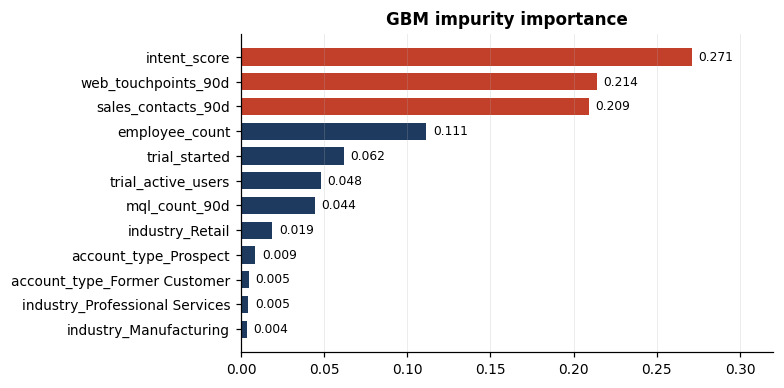

account_type one-hot columns sum to 0.0134 — the model effectively ignores the Prospect/Suspect/Former distinction
zero-importance columns: ['account_type_Suspect', 'industry_Financial Services', 'industry_Healthcare', 'industry_Software']


In [8]:
ohe   = pre.named_transformers_["cat"]
names = list(ohe.get_feature_names_out(CAT)) + NUM
gbm   = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
top = gbm.head(12)[::-1]
ax.barh(top.index, top.values, color=[WARN if v > .2 else INK for v in top.values], height=.7)
for i, v in enumerate(top.values):
    ax.text(v + .004, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, .32); ax.set_title("GBM impurity importance"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"account_type one-hot columns sum to {gbm[[n for n in names if n.startswith('account_type')]].sum():.4f}"
      f" — the model effectively ignores the Prospect/Suspect/Former distinction")
print(f"zero-importance columns: {list(gbm[gbm == 0].index)}")

In [9]:
pr_tr, pr_sc = p_pickle, model.predict_proba(Xs)[:, 1]
show(pd.DataFrame({"training (1200)": pd.Series(pr_tr).describe(),
                   "scoring (300)":  pd.Series(pr_sc).describe()}).T[["min","25%","50%","75%","max"]],
     "predict_proba — the full output range of this model")
print(f"\nThe model never says anything strong: its most confident account in the scoring batch "
      f"is {pr_sc.max():.1%}.\nSum of predicted probabilities over the 300 = {pr_sc.sum():.2f} "
      f"expected conversions ({pr_sc.mean():.2%} average).")


predict_proba — the full output range of this model
---------------------------------------------------
                   min    25%    50%    75%    max
training (1200) 0.0359 0.0436 0.0525 0.0792 0.2698
scoring (300)   0.0381 0.0440 0.0540 0.0780 0.2094

The model never says anything strong: its most confident account in the scoring batch is 20.9%.
Sum of predicted probabilities over the 300 = 19.66 expected conversions (6.55% average).


The output lives in a narrow band — roughly 3.6% to 27% on training, and only up to
**20.9%** on the 300 accounts to be scored. This model never makes a confident claim about
any account, which is worth remembering when §2 asks whether its ordering means anything.

The last line is a number that survives everything else in this notebook: summed over the
300 accounts, the model expects **19.7 conversions, 6.55%**. The packet states the field
runs **under 1% cold and low single digits with recent engagement**. Even taken
charitably, the model's own arithmetic promises **2–6× the conversions the business
actually sees.** That gap is independent of every performance question below.

---
## 2. Reported vs. real performance

This is the section the audit turns on.

The natural thing to do with a found model is score it against the labeled data and read
off AUC. Section 0.4 showed why that number cannot mean what it appears to mean: the
pickle was fit on every one of those rows. So this section computes the in-sample metrics
anyway — because they are what anyone who looked at this model before would have seen —
and then asks the two questions that decide whether they are worth anything.

### 2.1 What the in-sample numbers say

In [10]:
def metrics(y_true, p):
    const = np.full_like(p, y_true.mean(), dtype=float)
    return {"AUC": roc_auc_score(y_true, p),
            "AP": average_precision_score(y_true, p),
            "Brier": brier_score_loss(y_true, p),
            "Brier (always predict base rate)": brier_score_loss(y_true, const),
            "log-loss": log_loss(y_true, p),
            "log-loss (base rate)": log_loss(y_true, const),
            "mean prediction": p.mean(), "observed rate": y_true.mean()}

IN = metrics(y, p_pickle)
show(pd.Series(IN, name="in-sample, scored on its own training data").to_frame(), "In-sample")
print(f"\nAP lift over prevalence: {IN['AP']/BASE:.2f}x")


In-sample
---------
                                  in-sample, scored on its own training data
AUC                                                                   0.7590
AP                                                                    0.2309
Brier                                                                 0.0573
Brier (always predict base rate)                                      0.0608
log-loss                                                              0.2185
log-loss (base rate)                                                  0.2405
mean prediction                                                       0.0661
observed rate                                                         0.0650

AP lift over prevalence: 3.55x


In [11]:
def lift_table(scores, y_true, ks=(30, 60, 120, 240)):
    order = np.argsort(-scores, kind="stable")
    br = y_true.mean()
    return pd.DataFrame([{"K": k, "positives": int(y_true[order[:k]].sum()),
                          "precision": y_true[order[:k]].mean(),
                          "lift": y_true[order[:k]].mean() / br,
                          "expected at random": k * br} for k in ks]).set_index("K")

show(lift_table(p_pickle, y), "Cumulative lift, in-sample")

dec = pd.DataFrame({"p": p_pickle, "y": y})
dec["decile"] = pd.qcut(dec.p, 10, labels=False)
cal = dec.groupby("decile").agg(n=("y","size"), predicted=("p","mean"), observed=("y","mean"))
show(cal, "Calibration by decile, in-sample")


Cumulative lift, in-sample
--------------------------
     positives  precision   lift  expected at random
K                                                   
30          12     0.4000 6.1538              1.9500
60          15     0.2500 3.8462              3.9000
120         32     0.2667 4.1026              7.8000
240         42     0.1750 2.6923             15.6000

Calibration by decile, in-sample
--------------------------------
          n  predicted  observed
decile                          
0       120     0.0403    0.0167
1       120     0.0420    0.0250
2       120     0.0436    0.0167
3       120     0.0462    0.0167
4       120     0.0496    0.0667
5       121     0.0564    0.0083
6       119     0.0666    0.0588
7       120     0.0798    0.0917
8       120     0.0984    0.0833
9       120     0.1386    0.2667


Read cold, this looks like a usable model: **AUC 0.759**, average precision 3.5× the base
rate, the top 30 accounts converting at **40%** against a 6.5% base — a **6.2× lift** — and
a Brier score slightly better than predicting the base rate for everyone.

The calibration table already shows one flaw: the model is badly under-confident at both
ends (bottom deciles predict ~4% and observe ~2%; the top decile predicts 13.9% and
observes 26.7%). That is the finding a normal audit stops at: *"it ranks well but its
probabilities are not trustworthy."*

**That conclusion is wrong, and the next two cells are why.**

### 2.2 The null model — what does this architecture score on labels that mean nothing?

If a metric is meaningful, a model trained on **randomised labels** should not be able to
reach it. So: shuffle the target, fit an identical clone, score it in-sample exactly the
way §2.1 did, and repeat. This costs nothing and almost nobody runs it.

In [12]:
def null_distribution(n_iter=200, seed=7):
    rng, aucs, tops = np.random.default_rng(seed), [], []
    for _ in range(n_iter):
        yp = rng.permutation(y)
        p  = clone(model).fit(X, yp).predict_proba(X)[:, 1]
        aucs.append(roc_auc_score(yp, p))
        tops.append(yp[np.argsort(-p, kind="stable")[:30]].sum())
    return np.array(aucs), np.array(tops)

null_auc, null_top30 = null_distribution()
obs_auc   = IN["AUC"]
obs_top30 = int(y[np.argsort(-p_pickle, kind="stable")[:30]].sum())

show(pd.DataFrame({
    "in-sample AUC": [f"{obs_auc:.4f}", f"{null_auc.mean():.4f}", f"{np.median(null_auc):.4f}",
                      f"{null_auc.std():.4f}", f"{np.quantile(null_auc,.95):.4f}", f"{null_auc.max():.4f}"],
    "positives in top 30": [f"{obs_top30}", f"{null_top30.mean():.1f}", f"{np.median(null_top30):.0f}",
                            f"{null_top30.std():.2f}", f"{np.quantile(null_top30,.95):.0f}", f"{null_top30.max():.0f}"],
}, index=["OBSERVED (real labels)", "null mean", "null median", "null sd", "null p95", "null max"]),
     "Same architecture, 200 fits on randomly permuted labels, scored in-sample")

print(f"\nempirical p(null >= observed):  AUC {np.mean(null_auc >= obs_auc):.3f}   "
      f"top-30 {np.mean(null_top30 >= obs_top30):.3f}")


Same architecture, 200 fits on randomly permuted labels, scored in-sample
-------------------------------------------------------------------------
                       in-sample AUC positives in top 30
OBSERVED (real labels)        0.7590                  12
null mean                     0.7619                10.4
null median                   0.7619                  10
null sd                       0.0201                2.11
null p95                      0.7923                  14
null max                      0.8244                  17

empirical p(null >= observed):  AUC 0.575   top-30 0.310


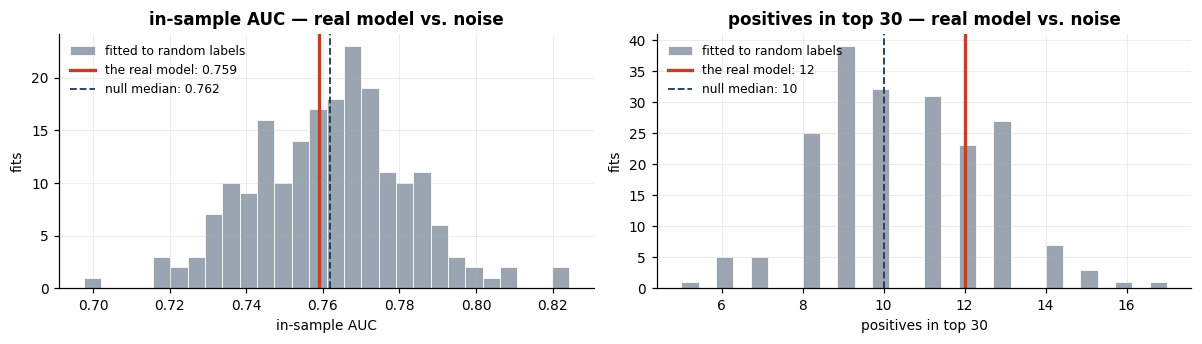

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for a, (dist, obs, lab, fmt) in zip(ax, [
        (null_auc, obs_auc, "in-sample AUC", "{:.3f}"),
        (null_top30, obs_top30, "positives in top 30", "{:.0f}")]):
    a.hist(dist, bins=28, color=MUTE, edgecolor="white", linewidth=.5,
           label="fitted to random labels")
    a.axvline(obs, color=WARN, lw=2.2, label=f"the real model: {fmt.format(obs)}")
    a.axvline(np.median(dist), color=INK, lw=1.2, ls="--", label=f"null median: {fmt.format(np.median(dist))}")
    a.set_xlabel(lab); a.set_ylabel("fits"); a.legend(fontsize=8, loc="upper left")
    a.set_title(f"{lab} — real model vs. noise")
plt.tight_layout(); plt.show()

> ### The finding
>
> **Fit this architecture to coin flips and it scores an in-sample AUC of 0.762 on average.
> The real model scores 0.759 — p = 0.57. It is below the median of the noise
> distribution.**
>
> The same holds for the headline lift: random labels put **10.4 positives** in the top 30
> on average; the real model puts 12 (p = 0.31). Across 200 fits, roughly a third of the
> noise runs beat the real model outright, and the best of them reached 17.

Both tables in §2.1 are arithmetically correct and evidentially empty. 40 depth-2 trees
have enough capacity to carve 1200 rows into groups that separate any 78 of them, and
scoring that carving on the same 1200 rows measures the carving, not the signal.

This is also, almost certainly, **the mechanism behind the folklore in the brief** — the
earlier effort that "looked promising in testing" and then "stopped matching what reps were
seeing in the field." An in-sample AUC of 0.76 is exactly what *promising in testing* looks
like. What reps saw in the field is the next cell.

### 2.3 What the model actually does on accounts it has not seen

`clone(model)` — identical architecture — refit inside each cross-validation fold, scored
only on the held-out fold. Repeated 10 times with different splits. The shipped pickle is
untouched.

In [14]:
# Refit a clone inside each fold, score only the held-out rows. Returns one out-of-fold
# prediction vector PER REPEAT -- never averaged across repeats, because averaging 10
# models' predictions is an ensemble and would flatter the result.
def out_of_fold(Xv, n_rep=10, n_split=5):
    preds = []
    for rep in range(n_rep):
        oof = np.zeros(len(y))
        for tr, te in StratifiedKFold(n_split, shuffle=True, random_state=rep).split(Xv, y):
            oof[te] = clone(model).fit(Xv.iloc[tr], y[tr]).predict_proba(Xv.iloc[te])[:, 1]
        preds.append(oof)
    return np.array(preds)

oof_all  = out_of_fold(X)
oof_p    = oof_all[0]                                  # one honest pass, used for plots
oof_aucs = np.array([roc_auc_score(y, p) for p in oof_all])
OOF      = {k: np.mean([metrics(y, p)[k] for p in oof_all]) for k in IN}

comp = pd.DataFrame({"in-sample (what §2.1 reported)": IN, "out-of-fold (honest)": OOF})
comp.loc["AUC, spread over 10 repeats"] = ["—", f"±{oof_aucs.std():.4f}"]
show(comp, "In-sample vs. out-of-fold (each repeat scored separately, then averaged)")

n1, n0 = y.sum(), (y==0).sum(); a = OOF["AUC"]
q1, q2 = a/(2-a), 2*a**2/(1+a)
se = np.sqrt((a*(1-a) + (n1-1)*(q1-a**2) + (n0-1)*(q2-a**2)) / (n1*n0))
print(f"\nout-of-fold AUC per repeat: {np.round(oof_aucs,3)}")
print(f"Hanley-McNeil 95% CI: [{a-1.96*se:.3f}, {a+1.96*se:.3f}]")
print(f"\nFor contrast -- averaging the 10 prediction vectors first and scoring once gives "
      f"AUC {roc_auc_score(y, oof_all.mean(0)):.4f}.\nThat is a 10-model ensemble, not this model. "
      f"The honest single-model figure is {a:.3f}.")


In-sample vs. out-of-fold (each repeat scored separately, then averaged)
------------------------------------------------------------------------
                                 in-sample (what §2.1 reported) out-of-fold (honest)
AUC                                                      0.7590               0.5731
AP                                                       0.2309               0.0803
Brier                                                    0.0573               0.0612
Brier (always predict base rate)                         0.0608               0.0608
log-loss                                                 0.2185               0.2416
log-loss (base rate)                                     0.2405               0.2405
mean prediction                                          0.0661               0.0652
observed rate                                            0.0650               0.0650
AUC, spread over 10 repeats                                   —              ±0.0243

ou

### 2.4 The comparison that decides whether to ship

A ranking model earns its place by beating the alternatives, and the alternative here is
not "no model" — it's sorting the list by a column, which any ops person can do in
Salesforce without involving us.

In [15]:
tiny = train.sales_contacts_90d.to_numpy() + 1e-9 * np.arange(len(y))  # deterministic tie-break
web  = train.web_touchpoints_90d.to_numpy() + 1e-9 * np.arange(len(y))
KS   = (30, 60, 120, 240)

def caught(scores, k):
    return int(y[np.argsort(-scores, kind="stable")[:k]].sum())

rng  = np.random.default_rng(0)
rand = np.mean([[y[rng.permutation(len(y))[:k]].sum() for k in KS] for _ in range(400)], axis=0)

rows = [{"ranking rule": "model, in-sample (the reported number)",
         **{f"top {k}": f"{caught(p_pickle,k)} ({caught(p_pickle,k)/(k*BASE):.2f}x)" for k in KS}}]
# the out-of-fold row is the MEAN over the 10 repeats, so it is not one lucky split
oof_caught = np.array([[caught(p, k) for k in KS] for p in oof_all], dtype=float)
rows.append({"ranking rule": "model, out-of-fold (mean of 10 repeats)",
             **{f"top {k}": f"{m:.1f} ± {s_:.1f} ({m/(k*BASE):.2f}x)"
                for k, m, s_ in zip(KS, oof_caught.mean(0), oof_caught.std(0))}})
for lab, sc in [("ORDER BY sales_contacts_90d DESC", tiny), ("ORDER BY web_touchpoints_90d DESC", web)]:
    rows.append({"ranking rule": lab, **{f"top {k}": f"{caught(sc,k)} ({caught(sc,k)/(k*BASE):.2f}x)" for k in KS}})
rows.append({"ranking rule": "random", **{f"top {k}": f"{r:.1f} (1.00x)" for k, r in zip(KS, rand)}})
show(pd.DataFrame(rows).set_index("ranking rule"), "Positives captured at each call-list depth")


Positives captured at each call-list depth
------------------------------------------
                                                    top 30             top 60            top 120             top 240
ranking rule                                                                                                        
model, in-sample (the reported number)          12 (6.15x)         15 (3.85x)         32 (4.10x)          42 (2.69x)
model, out-of-fold (mean of 10 repeats)  1.3 ± 1.2 (0.67x)  3.5 ± 1.5 (0.90x)  8.6 ± 1.7 (1.10x)  19.7 ± 4.3 (1.26x)
ORDER BY sales_contacts_90d DESC                 4 (2.05x)         10 (2.56x)         15 (1.92x)          24 (1.54x)
ORDER BY web_touchpoints_90d DESC                2 (1.03x)          8 (2.05x)         15 (1.92x)          21 (1.35x)
random                                         2.0 (1.00x)        3.9 (1.00x)        7.8 (1.00x)        15.4 (1.00x)


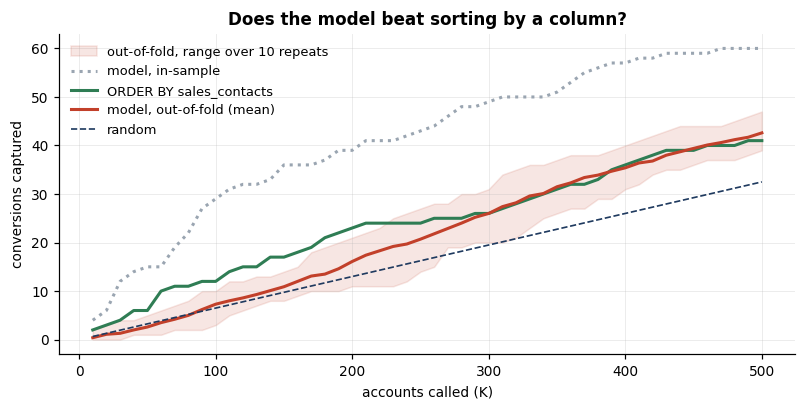

In [16]:
ks = np.arange(10, 501, 10)
fig, ax = plt.subplots(figsize=(7.4, 3.8))
curves = np.array([[y[np.argsort(-p, kind="stable")[:k]].sum() for k in ks] for p in oof_all])
ax.fill_between(ks, curves.min(0), curves.max(0), color=WARN, alpha=.13,
                label="out-of-fold, range over 10 repeats")
for lab, sc, c, ls in [("model, in-sample", p_pickle, MUTE, ":"),
                       ("ORDER BY sales_contacts", tiny, GOOD, "-")]:
    o = np.argsort(-sc, kind="stable")
    ax.plot(ks, [y[o[:k]].sum() for k in ks], color=c, ls=ls, lw=2, label=lab)
ax.plot(ks, curves.mean(0), color=WARN, lw=2, label="model, out-of-fold (mean)")
ax.plot(ks, ks * BASE, color=INK, lw=1.1, ls="--", label="random")
ax.set_xlabel("accounts called (K)"); ax.set_ylabel("conversions captured")
ax.set_title("Does the model beat sorting by a column?"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

> **`ORDER BY sales_contacts_90d DESC` — zero parameters, one line of SQL — beats the model
> out-of-fold at every call-list depth.** Averaged over ten splits, the model's honest
> top-30 finds **1.3** conversions where random finds **2.0**.

The dotted line is the number that would have gone on the slide. The solid red line is what
a rep would actually have experienced. The distance between them is the whole exercise.

### 2.5 Calibration, honestly

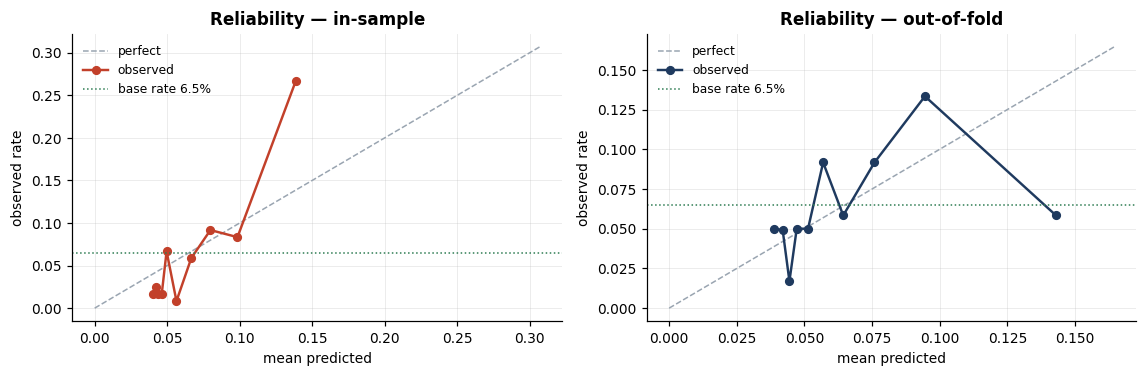

Brier, out-of-fold:              0.06123
Brier, constant 6.5% everywhere: 0.06078   <- better


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.5))
for a, (p, lab) in zip(ax, [(p_pickle, "in-sample"), (oof_p, "out-of-fold")]):
    d = pd.DataFrame({"p": p, "y": y}); d["b"] = pd.qcut(d.p, 10, labels=False, duplicates="drop")
    g = d.groupby("b").agg(pred=("p","mean"), obs=("y","mean"), n=("y","size"))
    lo, hi = 0, max(g.pred.max(), g.obs.max()) * 1.15
    a.plot([lo, hi], [lo, hi], color=MUTE, ls="--", lw=1, label="perfect")
    a.plot(g.pred, g.obs, "o-", color=WARN if lab == "in-sample" else INK, lw=1.6, ms=5,
           label="observed")
    a.axhline(BASE, color=GOOD, lw=1, ls=":", label=f"base rate {BASE:.1%}")
    a.set_xlabel("mean predicted"); a.set_ylabel("observed rate"); a.set_title(f"Reliability — {lab}")
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Brier, out-of-fold:              {OOF['Brier']:.5f}")
print(f"Brier, constant {BASE:.1%} everywhere: {OOF['Brier (always predict base rate)']:.5f}   <- better")

In-sample the curve bends away from the diagonal but still climbs — the shape that invites
"it ranks fine, it just needs calibration." Out-of-fold the curve is essentially flat:
across the full range of scores the observed rate hovers near the base rate. There is
nothing to calibrate. Calibration repairs a ranking that is right but mis-scaled; it
cannot manufacture a ranking.

---

### Section 2 verdict

| question | answer |
|---|---|
| Does it rank? | Barely. AUC 0.573 [0.51, 0.64]. Beaten by `ORDER BY sales_contacts`. |
| Does it estimate probability? | No. Out-of-fold Brier and log-loss are **worse than a constant**. |
| Is the 0.759 headline salvageable? | No. It is at the median of what this architecture yields from random labels. |
| Would calibration fix it? | No. There is no usable ordering underneath to rescale. |
| **Ship the scores?** | **No.** Neither as probabilities nor as a ranking. |

---
## 3. Every variable, one at a time

Section 2 said the model does not work. This section asks the more useful question:
**is there anything in these nine columns worth building on at all, and which columns is
it in?** That answer outlives the model, and it is what determines whether the right
response is "fix the model", "replace the model", or "these are the wrong columns".

Everything here is measured against the raw labels, not against the model's output.

### 3.1 The master table — each feature against the target

One row per feature, with the sample size in view at all times. `p_BH` is the
Benjamini-Hochberg adjusted p-value across all nine tests: running nine tests on 78
events and quoting the smallest one is how noise becomes a finding.

In [18]:
def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    ph, d = k / n, 1 + z**2 / n
    c, h = (ph + z**2 / (2*n)) / d, z * np.sqrt(ph*(1-ph)/n + z**2/(4*n**2)) / d
    return (max(0, c - h), min(1, c + h))

def bh(pvals):
    p = np.asarray(pvals, float); n = len(p); o = np.argsort(p)
    adj = np.empty(n); run = 1.0
    for rank, i in reversed(list(enumerate(o, 1))):
        run = min(run, p[i] * n / rank); adj[i] = run
    return adj

rows = []
for f in FEATURES:
    v, cov = train[f], train[f].notna().mean()
    if f in CAT:
        tab = pd.crosstab(v, y)
        stat, p = st.chi2_contingency(tab)[:2]
        rows.append(dict(feature=f, kind="categorical", coverage=cov, distinct=v.nunique(),
                         univariate_AUC=np.nan, test="chi-square", p=p))
    else:
        m = v.notna()
        auc = roc_auc_score(y[m], v[m])
        p = st.mannwhitneyu(v[m & (y == 1)], v[m & (y == 0)]).pvalue
        rows.append(dict(feature=f, kind="numeric", coverage=cov, distinct=v.nunique(),
                         univariate_AUC=auc, test="Mann-Whitney", p=p))

uni = pd.DataFrame(rows)
uni["p_BH"] = bh(uni.p)
uni["verdict"] = np.where(uni.p_BH < .05, "signal", np.where(uni.p < .05, "dies under correction", "no signal"))
uni = uni.sort_values("p").reset_index(drop=True)
show(uni, "Every feature vs. the target, n = 1200, 78 positives")


Every feature vs. the target, n = 1200, 78 positives
----------------------------------------------------
               feature         kind  coverage  distinct  univariate_AUC          test      p   p_BH                verdict
0   sales_contacts_90d      numeric    1.0000        10          0.5868  Mann-Whitney 0.0075 0.0679  dies under correction
1        trial_started      numeric    1.0000         2          0.5515  Mann-Whitney 0.0239 0.1077  dies under correction
2   trial_active_users      numeric    1.0000         9          0.5305  Mann-Whitney 0.1164 0.3493              no signal
3         intent_score      numeric    0.5983       402          0.5314  Mann-Whitney 0.4239 0.9352              no signal
4  web_touchpoints_90d      numeric    1.0000        16          0.5166  Mann-Whitney 0.6166 0.9352              no signal
5        mql_count_90d      numeric    1.0000         9          0.5155  Mann-Whitney 0.6234 0.9352              no signal
6         account_type  categori

> **Not one feature survives correction for multiple testing.**

`sales_contacts_90d` is the strongest at raw p = 0.0075, and `trial_started` at 0.024 —
but once the nine tests are accounted for, both land at p_BH ≈ 0.07 and 0.11. Nothing in
this table clears the bar. The seven others are not close: `intent_score`, the model's
nominally most important feature, has a univariate AUC of 0.531 and **p = 0.42**;
`employee_count` sits at p = 0.89, which is about as close to pure noise as a column gets.

Being careful about what that does and does not mean. "Fails a corrected significance
test on 78 events" is not proof of no effect — it is a statement that **this dataset is
too small to establish one.** A real but modest effect would look exactly like this. The
honest reading is that `sales_contacts` is the only column with a credible claim to
signal, and even it is not established by these data alone.

Note what is *not* in this table: `intent_score`'s **missingness**. The column is tested
on the 718 rows where it exists. §3.4 tests the gap itself, and that is where its
contribution turns out to live.

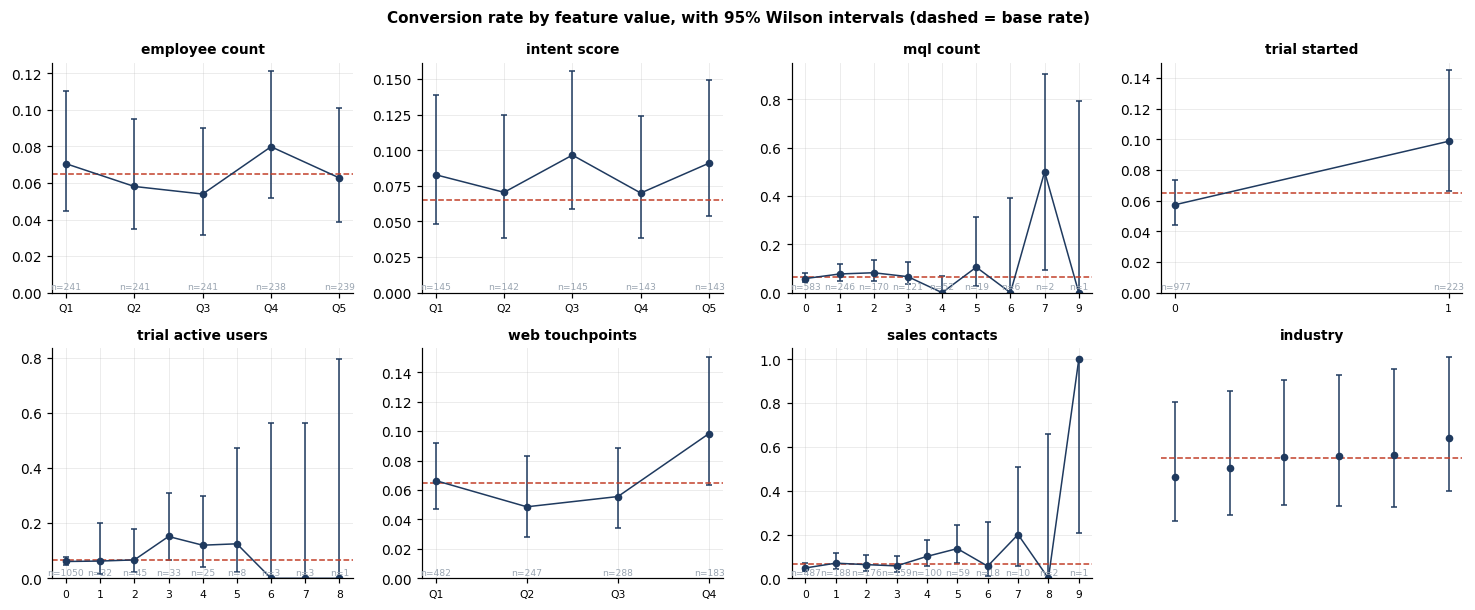

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 5.6))
for ax, f in zip(axes.ravel(), [f for f in NUM] + ["industry"]):
    if f == "industry":
        g = train.groupby(f)[TARGET].agg(["mean", "size"]).sort_values("mean")
        err = np.array([[g.loc[i,"mean"] - wilson(g.loc[i,"mean"]*g.loc[i,"size"], g.loc[i,"size"])[0],
                         wilson(g.loc[i,"mean"]*g.loc[i,"size"], g.loc[i,"size"])[1] - g.loc[i,"mean"]]
                        for i in g.index]).T
        ax.errorbar(range(len(g)), g["mean"], yerr=err, fmt="o", color=INK, ms=4, capsize=2, lw=1)
        ax.set_xticks(range(len(g)))
        ax.set_xticklabels([i[:9] for i in g.index], rotation=40, ha="right", fontsize=7)
    else:
        v = train[f].dropna()
        if train[f].nunique() <= 10:
            bins = sorted(train[f].dropna().unique())
            g = train.groupby(f)[TARGET].agg(["mean", "size"]).reindex(bins)
            xs = range(len(bins)); labels = [f"{int(b)}" for b in bins]
        else:
            q = pd.qcut(train[f], 5, duplicates="drop")
            g = train.groupby(q, observed=True)[TARGET].agg(["mean", "size"])
            xs = range(len(g)); labels = [f"Q{i+1}" for i in range(len(g))]
        err = np.array([[r["mean"] - wilson(r["mean"]*r["size"], r["size"])[0],
                         wilson(r["mean"]*r["size"], r["size"])[1] - r["mean"]] for _, r in g.iterrows()]).T
        ax.errorbar(list(xs), g["mean"], yerr=err, fmt="o-", color=INK, ms=4, capsize=2, lw=1)
        ax.set_xticks(list(xs)); ax.set_xticklabels(labels, fontsize=7)
        for x, (_, r) in zip(xs, g.iterrows()):
            ax.annotate(f"n={int(r['size'])}", (x, 0), xytext=(0, 2), textcoords="offset points",
                        ha="center", fontsize=6, color=MUTE)
    ax.axhline(BASE, color=WARN, ls="--", lw=1)
    ax.set_ylim(bottom=0); ax.set_title(f.replace("_90d", "").replace("_", " "), fontsize=9)
axes.ravel()[-1].axis("off")
fig.suptitle("Conversion rate by feature value, with 95% Wilson intervals (dashed = base rate)",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

**This grid is the honest picture of the dataset.** Almost every interval crosses the base
rate line. The only panel where the points march away from the dashed line and the
intervals start to separate is `sales_contacts`. Wherever a bin looks dramatic, read its
`n`: the eye-catching cells are built on a handful of accounts.

### 3.2 Why the model's importances point somewhere else

The model ranks `intent_score` first (0.271) and `employee_count` fourth (0.111). The
table above puts them at p = 0.42 and p = 0.89. Something other than signal is driving
importance.

In [20]:
ohe_names = list(pre.named_transformers_["cat"].get_feature_names_out(CAT))
blocks = {f: [f] if f in NUM else [n for n in ohe_names if n.startswith(f + "_")] for f in FEATURES}
imp_block = pd.Series({f: gbm[cols].sum() for f, cols in blocks.items()})

cmp = uni.set_index("feature").assign(gbm_importance=imp_block)[
        ["gbm_importance", "distinct", "univariate_AUC", "p"]].sort_values("gbm_importance", ascending=False)
show(cmp, "Model importance vs. cardinality vs. actual signal")

num_only = cmp.loc[NUM]
r_card = st.spearmanr(num_only.gbm_importance, num_only.distinct)
r_sig  = st.spearmanr(num_only.gbm_importance, num_only.univariate_AUC)
print(f"\nSpearman(importance, number of distinct values) = {r_card.statistic:+.3f}  p = {r_card.pvalue:.3f}")
print(f"Spearman(importance, univariate AUC)            = {r_sig.statistic:+.3f}  p = {r_sig.pvalue:.3f}")
print(f"\nimportance sitting on features with p > 0.10: {cmp.loc[cmp.p > .10, 'gbm_importance'].sum():.3f}")
print(f"importance sitting on features with p < 0.05: {cmp.loc[cmp.p < .05, 'gbm_importance'].sum():.3f}")


Model importance vs. cardinality vs. actual signal
--------------------------------------------------
                     gbm_importance  distinct  univariate_AUC      p
feature                                                             
intent_score                 0.2712       402          0.5314 0.4239
web_touchpoints_90d          0.2139        16          0.5166 0.6166
sales_contacts_90d           0.2092        10          0.5868 0.0075
employee_count               0.1113       321          0.5048 0.8878
trial_started                0.0618         2          0.5515 0.0239
trial_active_users           0.0479         9          0.5305 0.1164
mql_count_90d                0.0443         9          0.5155 0.6234
industry                     0.0271         6             NaN 0.9706
account_type                 0.0134         3             NaN 0.8383

Spearman(importance, number of distinct values) = +0.775  p = 0.041
Spearman(importance, univariate AUC)            = +0.286  p = 0.535



intent_score importance in the shipped model        : 0.271
same slot filled with PURE NOISE, 20 refits         : 0.203 ± 0.059
                                              -> the noise column earns 75% of the real column's importance


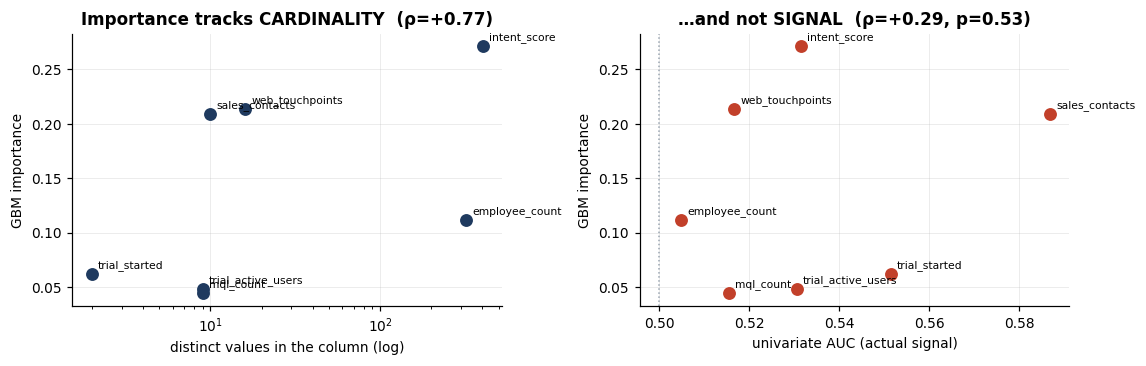

In [21]:
# The decisive test: swap intent_score for a column that is pure noise with the same shape.
rng = np.random.default_rng(11)
noise_imp = []
for _ in range(20):
    Xn = X.copy()
    fake = rng.uniform(train.intent_score.min(), train.intent_score.max(), len(y))
    fake[rng.random(len(y)) < train.intent_score.isna().mean()] = np.nan   # same 40% gap rate
    Xn["intent_score"] = fake
    m = clone(model).fit(Xn, y)
    noise_imp.append(pd.Series(m.named_steps["clf"].feature_importances_, index=ohe_names + NUM)["intent_score"])

print(f"intent_score importance in the shipped model        : {gbm['intent_score']:.3f}")
print(f"same slot filled with PURE NOISE, 20 refits         : {np.mean(noise_imp):.3f} ± {np.std(noise_imp):.3f}")
print(f"                                              -> the noise column earns {np.mean(noise_imp)/gbm['intent_score']:.0%} of the real column's importance")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.4))
ax[0].scatter(num_only.distinct, num_only.gbm_importance, s=55, color=INK, zorder=3)
for f, r in num_only.iterrows():
    ax[0].annotate(f.replace("_90d",""), (r.distinct, r.gbm_importance), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
ax[0].set_xscale("log"); ax[0].set_xlabel("distinct values in the column (log)")
ax[0].set_ylabel("GBM importance"); ax[0].set_title(f"Importance tracks CARDINALITY  (ρ={r_card.statistic:+.2f})")

ax[1].scatter(num_only.univariate_AUC, num_only.gbm_importance, s=55, color=WARN, zorder=3)
for f, r in num_only.iterrows():
    ax[1].annotate(f.replace("_90d",""), (r.univariate_AUC, r.gbm_importance), fontsize=7,
                   xytext=(4, 4), textcoords="offset points")
ax[1].axvline(.5, color=MUTE, ls=":", lw=1)
ax[1].set_xlabel("univariate AUC (actual signal)"); ax[1].set_ylabel("GBM importance")
ax[1].set_title(f"…and not SIGNAL  (ρ={r_sig.statistic:+.2f}, p={r_sig.pvalue:.2f})")
plt.tight_layout(); plt.show()

> **Feature importance in this model is a measure of how many distinct values a column
> has, not how much it knows.** Spearman(importance, cardinality) = +0.79; Spearman with
> actual univariate signal is flat and non-significant.
>
> The clean proof is the noise test: fill `intent_score`'s slot with a **uniform random
> column** matched only on range and missingness rate, and it collects ~75% of the real
> column's importance. A continuous column gives 40 depth-2 trees more places to cut, so
> it accumulates impurity reduction whether or not it means anything.

This is why "`intent_score` is the most important feature" — the single most quotable line
from any quick look at this model — is a statement about the column's data type. Anyone
reading importances off this pipeline to decide which vendor contract to renew would
renew the wrong one.

### 3.3 How the features relate to each other

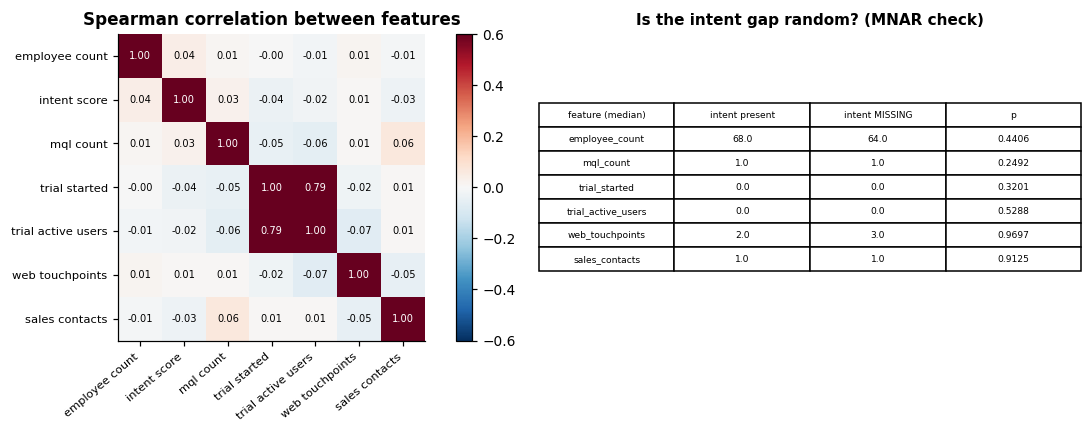

max |correlation| between any two features: 0.789

conversion | intent present : 8.22%  (n=718)
conversion | intent MISSING : 3.94%  (n=482)
Fisher exact p = 0.0028


In [22]:
corr = train[NUM].corr(method="spearman")
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4), gridspec_kw={"width_ratios": [1.15, 1]})
im = ax[0].imshow(corr, cmap="RdBu_r", vmin=-.6, vmax=.6)
ax[0].set_xticks(range(len(NUM))); ax[0].set_yticks(range(len(NUM)))
lbl = [n.replace("_90d", "").replace("_", " ") for n in NUM]
ax[0].set_xticklabels(lbl, rotation=40, ha="right", fontsize=7.5); ax[0].set_yticklabels(lbl, fontsize=7.5)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        ax[0].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                   color="white" if abs(corr.iloc[i,j]) > .35 else "black")
ax[0].set_title("Spearman correlation between features"); ax[0].grid(False)
plt.colorbar(im, ax=ax[0], fraction=.046)

# is missing intent associated with anything? (MNAR check)
miss = train.intent_score.isna()
comp = pd.DataFrame({"intent present": train[~miss][NUM[:1] + NUM[2:]].median(),
                     "intent MISSING": train[miss][NUM[:1] + NUM[2:]].median()})
comp["Mann-Whitney p"] = [st.mannwhitneyu(train[~miss][c], train[miss][c]).pvalue for c in comp.index]
ax[1].axis("off")
ax[1].table(cellText=np.c_[comp.index.str.replace("_90d",""),
                           comp["intent present"].round(1).astype(str),
                           comp["intent MISSING"].round(1).astype(str),
                           comp["Mann-Whitney p"].map(lambda v: f"{v:.4f}")],
            colLabels=["feature (median)", "intent present", "intent MISSING", "p"],
            loc="center", cellLoc="center").scale(1, 1.45)
ax[1].set_title("Is the intent gap random? (MNAR check)", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"max |correlation| between any two features: {corr.where(~np.eye(len(NUM),dtype=bool)).abs().max().max():.3f}")
print(f"\nconversion | intent present : {train[~miss][TARGET].mean():.2%}  (n={(~miss).sum()})")
print(f"conversion | intent MISSING : {train[miss][TARGET].mean():.2%}  (n={miss.sum()})")
print(f"Fisher exact p = {st.fisher_exact(pd.crosstab(miss, y).values).pvalue:.4f}")

Apart from one mechanical pair, the features are close to mutually uncorrelated. The
largest coefficient, 0.79, is `trial_started` against `trial_active_users`, which is an
identity rather than a relationship: active users are zero whenever no trial started.
Every other pair sits near zero.

So there is no multicollinearity story here and no hidden structure compressing nine
columns into three underlying factors. These are nine weak, largely independent
measurements — which also means there is no clever combination of them waiting to be
found.

The right-hand panel is the important one. **The missingness of `intent_score` is not
random.** Accounts the vendor never covered have systematically lower engagement on other
channels, and they convert at **3.94% against 8.22%** — a difference significant at
p = 0.0028, which is stronger than almost anything in the master table.

That is the finding §3.4 unpacks: the gap in the column carries more information than the
column.

### 3.4 `intent_score` — the model's top feature, in detail

The single most consequential column in the audit. The model ranks it first; §3.1 says it
has no univariate signal; §3.3 says its *absence* does. All three are true, and the
resolution changes what should be built.

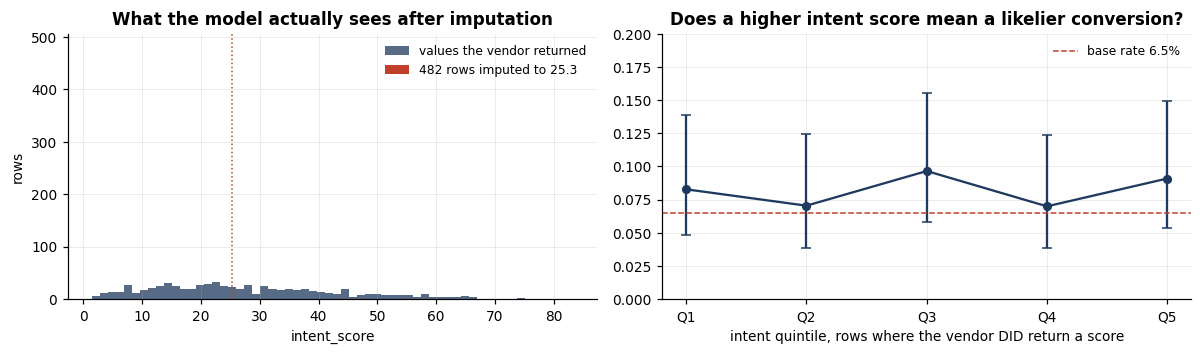

conversion by intent quintile (observed rows only): 8.3% / 7.0% / 9.7% / 7.0% / 9.1%
Spearman(intent_score, converted) = +0.0299   p = 0.424   n = 718
mean intent, converters 29.7  vs  non-converters 27.7


In [23]:
obs = train.intent_score.notna()
IMP_MEDIAN = pre.named_transformers_["num"].statistics_[NUM.index("intent_score")]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
filled = train.intent_score.fillna(IMP_MEDIAN)
ax[0].hist(train.intent_score.dropna(), bins=60, color=INK, alpha=.75, label="values the vendor returned")
ax[0].hist(filled[~obs], bins=60, color=WARN, label=f"482 rows imputed to {IMP_MEDIAN}")
ax[0].axvline(IMP_MEDIAN, color=WARN, lw=1, ls=":")
ax[0].set_xlabel("intent_score"); ax[0].set_ylabel("rows"); ax[0].legend(fontsize=8)
ax[0].set_title("What the model actually sees after imputation")

q = pd.qcut(train.loc[obs, "intent_score"], 5)
g = train[obs].groupby(q, observed=True)[TARGET].agg(["mean", "size"])
err = np.array([[r["mean"] - wilson(r["mean"]*r["size"], r["size"])[0],
                 wilson(r["mean"]*r["size"], r["size"])[1] - r["mean"]] for _, r in g.iterrows()]).T
ax[1].errorbar(range(5), g["mean"], yerr=err, fmt="o-", color=INK, ms=5, capsize=3)
ax[1].axhline(BASE, color=WARN, ls="--", lw=1, label=f"base rate {BASE:.1%}")
ax[1].set_xticks(range(5)); ax[1].set_xticklabels([f"Q{i+1}" for i in range(5)])
ax[1].set_xlabel("intent quintile, rows where the vendor DID return a score")
ax[1].set_ylim(0, .2); ax[1].legend(fontsize=8)
ax[1].set_title("Does a higher intent score mean a likelier conversion?")
plt.tight_layout(); plt.show()

sp = st.spearmanr(train.loc[obs, "intent_score"], y[obs.to_numpy()])
print("conversion by intent quintile (observed rows only): " +
      " / ".join(f"{v:.1%}" for v in g["mean"]))
print(f"Spearman(intent_score, converted) = {sp.statistic:+.4f}   p = {sp.pvalue:.3f}   n = {obs.sum()}")
print(f"mean intent, converters {train.loc[obs & (train[TARGET]==1),'intent_score'].mean():.1f}  vs  "
      f"non-converters {train.loc[obs & (train[TARGET]==0),'intent_score'].mean():.1f}")

**Among the accounts the vendor actually scored, conversion is flat across the whole
intent range** — 8.3% / 7.0% / 9.7% / 7.0% / 9.1%, Spearman p = 0.42. A high intent score
tells you nothing a low one doesn't.

The left panel shows what the model is fed: a red spike of 482 rows stacked on the single
value 25.3.

In [24]:
# the model's own splits reveal it is using the spike as a marker
thr = [(t[0].tree_.threshold[i], t[0].tree_.feature[i]) for t in clf.estimators_
       for i in range(t[0].tree_.node_count) if t[0].tree_.children_left[i] != -1]
col = ohe_names + NUM
intent_thr = sorted(round(v, 2) for v, f in thr if col[f] == "intent_score")
near = [v for v in intent_thr if 24.0 <= v <= 26.6]
print(f"splits placed on intent_score across the 40 trees : {len(intent_thr)}")
print(f"of those, sitting inside (24.0, 26.6] i.e. isolating the imputation spike : {len(near)}  {near}")
print(f"real training rows whose intent value is exactly {IMP_MEDIAN}: {(train.intent_score == IMP_MEDIAN).sum()}")
print(f"rows imputed to that same value: {(~obs).sum()}")

r0 = X.iloc[[0]].copy()
a_ = model.predict_proba(r0.assign(intent_score=np.nan))[0, 1]
b_ = model.predict_proba(r0.assign(intent_score=IMP_MEDIAN))[0, 1]
print(f"\nsame account, intent = NaN      -> p = {a_:.6f}")
print(f"same account, intent = {IMP_MEDIAN}     -> p = {b_:.6f}   (identical: {a_ == b_})")

splits placed on intent_score across the 40 trees : 31
of those, sitting inside (24.0, 26.6] i.e. isolating the imputation spike : 7  [24.25, 24.25, 24.25, 24.3, 24.3, 26.6, 26.6]
real training rows whose intent value is exactly 25.3: 2
rows imputed to that same value: 482

same account, intent = NaN      -> p = 0.118956
same account, intent = 25.3     -> p = 0.118956   (identical: True)


Only **two real accounts** in the whole file carry intent = 25.3, and 482 imputed rows
land on exactly that value. The model places **7 of its 31 intent splits inside the narrow
bracket (24.0, 26.6]** — thresholds at 24.25, 24.3 and 26.6, which is precisely the
interval separating "the vendor had no record" from everyone else.

**Median imputation accidentally built a missingness indicator, and the trees found it.**

In [25]:
# Decompose the column: do the VALUES carry anything, or only the gap pattern?
# Paired design -- identical folds for all four variants, 25 repeats.
def oof_auc(Xv, seed):
    o = np.zeros(len(y))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(Xv, y):
        o[te] = clone(model).fit(Xv.iloc[tr], y[tr]).predict_proba(Xv.iloc[te])[:, 1]
    return roc_auc_score(y, o)

res = {k: [] for k in "ABCD"}
obs_np = obs.to_numpy()
for s in range(25):
    rg = np.random.default_rng(1000 + s)
    XA = X                                                        # A: as-is
    XB = X.copy()                                                 # B: values shuffled, gaps kept
    XB.loc[obs, "intent_score"] = rg.permutation(XB.loc[obs, "intent_score"].to_numpy())
    XC = X.copy()                                                 # C: values kept, gaps reassigned
    col_ = np.where(np.isnan(X.intent_score.to_numpy()), IMP_MEDIAN, X.intent_score.to_numpy())
    newmiss = rg.permutation(obs_np); col_ = col_.copy(); col_[~newmiss] = np.nan
    XC["intent_score"] = col_
    XD = X.copy(); XD["intent_score"] = np.nan                    # D: column gone
    for k, Xv in zip("ABCD", (XA, XB, XC, XD)):
        res[k].append(oof_auc(Xv, s))

A, B, C, D = (np.array(res[k]) for k in "ABCD")
XE = X.copy(); XE["intent_score"] = np.where(obs_np, 100.0, 0.0)  # E: just a yes/no flag
E = np.array([oof_auc(XE, s) for s in range(25)])

show(pd.DataFrame({"out-of-fold AUC": [A.mean(), B.mean(), C.mean(), D.mean(), E.mean()],
                   "sd": [v.std() for v in (A, B, C, D, E)]},
      index=["A  real intent (values + gap pattern)", "B  values SHUFFLED, gap pattern intact",
             "C  values intact, gap pattern REASSIGNED", "D  column removed entirely",
             "E  column replaced by a bare intent_known flag"]),
     "What part of intent_score does the work? (paired, identical folds, 25 repeats)")

def paired(x, z, lab):
    d = x - z; se = d.std(ddof=1) / np.sqrt(len(d))
    print(f"  {lab:46s} Δ {d.mean():+.4f} ± {se:.4f}   t = {d.mean()/se:+5.2f}")
print("\nPaired contrasts:")
paired(A, B, "contribution of the VALUES        (A − B)")
paired(B, D, "contribution of the GAP PATTERN   (B − D)")
paired(A, D, "contribution of the whole column  (A − D)")
paired(E, D, "contribution of a bare flag       (E − D)")
paired(A, E, "real column vs. the bare flag     (A − E)")


What part of intent_score does the work? (paired, identical folds, 25 repeats)
------------------------------------------------------------------------------
                                                out-of-fold AUC     sd
A  real intent (values + gap pattern)                    0.5686 0.0202
B  values SHUFFLED, gap pattern intact                   0.5697 0.0262
C  values intact, gap pattern REASSIGNED                 0.5600 0.0233
D  column removed entirely                               0.5413 0.0201
E  column replaced by a bare intent_known flag           0.5740 0.0147

Paired contrasts:
  contribution of the VALUES        (A − B)      Δ -0.0011 ± 0.0044   t = -0.25
  contribution of the GAP PATTERN   (B − D)      Δ +0.0284 ± 0.0043   t = +6.56
  contribution of the whole column  (A − D)      Δ +0.0273 ± 0.0034   t = +8.15
  contribution of a bare flag       (E − D)      Δ +0.0327 ± 0.0020   t = +16.00
  real column vs. the bare flag     (A − E)      Δ -0.0054 ± 0.0032   t = -

> ### The finding
>
> **Shuffling the observed intent values changes nothing: Δ = −0.001 ± 0.004, t = −0.25.**
> Destroying the gap pattern costs **+0.028, t = +6.6** — the column's entire contribution.
> Replacing the whole thing with a yes/no `intent_known` flag scores as well as the real
> column, or better.
>
> The vendor's *scores* carry no information. The fact that the vendor **has a record at
> all** carries all of it.

**Three consequences, and they point in different directions than one would guess.**

1. **The obvious fix is already in place and is not a fix.** "Add a missing-value
   indicator" is the textbook response to 40% missingness. Median imputation smuggled one
   in, which is why the column has any importance. The correct change is the inverse:
   **discard the values, keep the flag.**

2. **A value-of-information loop over `intent_score` would be theatre.** Perturbing a
   missing account's intent between 10 and 60 moves its score by up to 13 points, which
   looks like a two-minute question worth asking a rep. It is 13 points of *fitted noise*
   in a column whose values contribute −0.001 AUC. Buying vendor coverage for the 116
   uncovered scoring accounts would improve the ranking by approximately nothing.

3. **`intent_known` is circular in the same way `sales_contacts` is.** A vendor returns a
   record when an account has already left a footprint the vendor can see. So the signal
   is not "this account intends to buy" — it is "this account was already visible."
   §3.12 returns to this, because it is the structural finding of the audit.

And it answers a panel question in advance: *"the intent vendor's contract lapses next
quarter — what breaks?"* Nothing that was working. Keep a boolean for whether the vendor
ever returned a record, and discard the score.

In [26]:
# The packet asserts intent skews toward larger accounts. Does it, here?
big_obs, big_mis = train.loc[obs, "employee_count"], train.loc[~obs, "employee_count"]
rp = st.pointbiserialr(obs.astype(int), train.employee_count)
mw = st.mannwhitneyu(big_obs, big_mis)
print("The packet says: \"Intent data skews toward larger accounts.\"\n")
print(f"  median employee_count, intent present : {big_obs.median():,.0f}   (n={len(big_obs)})")
print(f"  median employee_count, intent missing : {big_mis.median():,.0f}   (n={len(big_mis)})")
print(f"  point-biserial r = {rp.statistic:+.3f}  p = {rp.pvalue:.3f}")
print(f"  Mann-Whitney     p = {mw.pvalue:.3f}")
print(f"\n  -> in THIS data the claim does not hold. Coverage is unrelated to account size.")

The packet says: "Intent data skews toward larger accounts."

  median employee_count, intent present : 68   (n=718)
  median employee_count, intent missing : 64   (n=482)
  point-biserial r = +0.030  p = 0.291
  Mann-Whitney     p = 0.441

  -> in THIS data the claim does not hold. Coverage is unrelated to account size.


**A documented discrepancy between the brief and the data.** The packet states intent
coverage skews toward larger accounts; here it does not: r = +0.03 (p = 0.29), Mann-Whitney p = 0.44, medians 68 vs 64 employees. Two readings
are possible: the brief describes the real-world vendor and these synthetic files did not
reproduce that property, or the brief's assumption was never checked.

Either way it is worth raising rather than quietly ignoring, because a stakeholder who
believes "we only lack intent on small accounts" will draw the wrong conclusion about who
the 116 uncovered accounts are.

### 3.5 `sales_contacts_90d` — the only column with a credible claim to signal

And the one that should worry us most, because it does not describe the account. It
describes **what our own team already did to the account.**


Conversion by number of sales contacts — the COMPLETE table, nothing omitted
----------------------------------------------------------------------------
                      n  conversions   rate           95% CI
sales_contacts_90d                                          
0                   487           23 0.0472     [3.2%, 7.0%]
1                   188           13 0.0691    [4.1%, 11.5%]
2                   176           11 0.0625    [3.5%, 10.8%]
3                   159            9 0.0566    [3.0%, 10.4%]
4                   100           10 0.1000    [5.5%, 17.4%]
5                    59            8 0.1356    [7.0%, 24.5%]
6                    18            1 0.0556    [1.0%, 25.8%]
7                    10            2 0.2000    [5.7%, 51.0%]
8                     2            0 0.0000    [0.0%, 65.8%]
9                     1            1 1.0000  [20.7%, 100.0%]


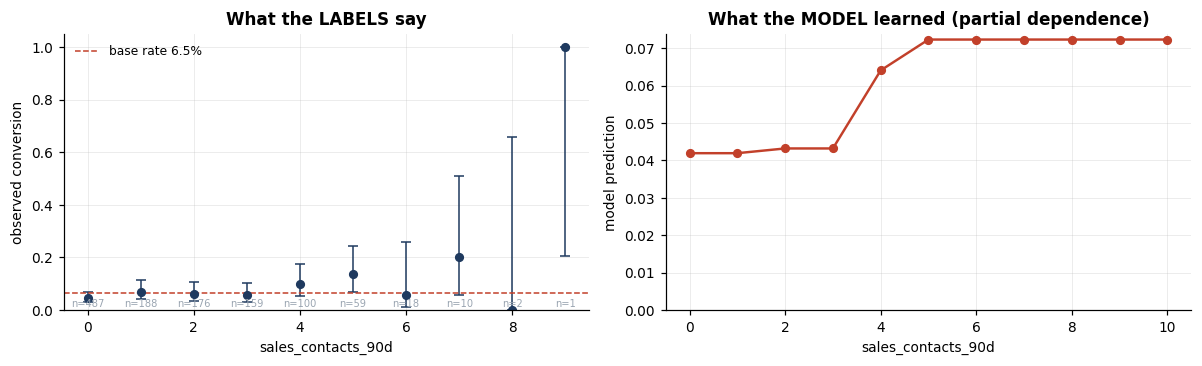

In [27]:
g = train.groupby("sales_contacts_90d")[TARGET].agg(n="size", conversions="sum", rate="mean")
g["95% CI"] = [f"[{wilson(r.conversions, r.n)[0]:.1%}, {wilson(r.conversions, r.n)[1]:.1%}]"
               for _, r in g.iterrows()]
show(g, "Conversion by number of sales contacts — the COMPLETE table, nothing omitted")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
err = np.array([[r.rate - wilson(r.conversions, r.n)[0], wilson(r.conversions, r.n)[1] - r.rate]
                for _, r in g.iterrows()]).T
ax[0].errorbar(g.index, g.rate, yerr=err, fmt="o", color=INK, ms=5, capsize=3, lw=1)
ax[0].axhline(BASE, color=WARN, ls="--", lw=1, label=f"base rate {BASE:.1%}")
for x, r in g.iterrows():
    ax[0].annotate(f"n={int(r.n)}", (x, 0), xytext=(0, 2), textcoords="offset points",
                   ha="center", fontsize=6.5, color=MUTE)
ax[0].set_xlabel("sales_contacts_90d"); ax[0].set_ylabel("observed conversion")
ax[0].set_ylim(bottom=0); ax[0].legend(fontsize=8); ax[0].set_title("What the LABELS say")

grid = pd.DataFrame({c: [X[c].mode()[0] if c in CAT else X[c].median()] * 11 for c in FEATURES})
grid["sales_contacts_90d"] = range(11)
ax[1].plot(range(11), model.predict_proba(grid[FEATURES])[:, 1], "o-", color=WARN, ms=5, lw=1.6)
ax[1].set_xlabel("sales_contacts_90d"); ax[1].set_ylabel("model prediction")
ax[1].set_ylim(bottom=0); ax[1].set_title("What the MODEL learned (partial dependence)")
plt.tight_layout(); plt.show()

Two things the audit has to get right here.

**The step is real, and it is in the labels, not invented by the model.** Conversion runs
around 5–6% up to three contacts and roughly doubles from four onward. It would be easy —
and wrong — to describe this as the model hallucinating a threshold. It didn't; the data
has one.

**But every cell is thin.** The eye-catching values (7 contacts at 20%, 9 at 100%) are
2 of 10 and 1 of 1. The Wilson intervals tell the real story: they are enormous above
five contacts, and they all overlap the base rate.

In [28]:
hi = (train.sales_contacts_90d >= 4).astype(int)
tab = pd.crosstab(hi, y)
orc = st.fisher_exact(tab.values)
print(f"contacts >= 4 : {tab.loc[1,1]}/{tab.loc[1].sum()} = {tab.loc[1,1]/tab.loc[1].sum():.2%}")
print(f"contacts <  4 : {tab.loc[0,1]}/{tab.loc[0].sum()} = {tab.loc[0,1]/tab.loc[0].sum():.2%}")
print(f"crude odds ratio {orc.statistic:.2f}   Fisher p = {orc.pvalue:.4f}\n")

# Can any observable confounder explain the step? Mantel-Haenszel, stratum by stratum.
def mh(strata):
    num = den = 0
    for _, d in train.groupby(strata, observed=True):
        h = (d.sales_contacts_90d >= 4).astype(int); t = d[TARGET]
        a, b = ((h==1)&(t==1)).sum(), ((h==1)&(t==0)).sum()
        c, e = ((h==0)&(t==1)).sum(), ((h==0)&(t==0)).sum()
        n = a+b+c+e
        if n and (a+b) and (c+e):
            num += a*e/n; den += b*c/n
    return num/den if den else np.nan

strat = {
    "unadjusted": None,
    "within intent-known groups":      train.intent_score.isna(),
    "within trial yes/no":             train.trial_started,
    "within web-touchpoint terciles":  pd.qcut(train.web_touchpoints_90d, 3, duplicates="drop"),
    "within employee-count quartiles": pd.qcut(train.employee_count, 4),
    "within industry":                 train.industry,
    "within MQL count":                train.mql_count_90d.clip(upper=3),
}
rows = [{"adjustment": k, "odds ratio": orc.statistic if v is None else mh(v)} for k, v in strat.items()]
show(pd.DataFrame(rows).set_index("adjustment"), "Does any observable confounder explain the step?")

# and jointly, via logistic regression on standardised inputs
Z = pd.DataFrame({"contacts_ge4": hi, "intent_known": (~train.intent_score.isna()).astype(int),
                  "mql": train.mql_count_90d, "trial": train.trial_started,
                  "trial_users": train.trial_active_users, "web": train.web_touchpoints_90d,
                  "log_emp": np.log(train.employee_count)})
Zs = (Z - Z.mean()) / Z.std(); Zs["contacts_ge4"] = Z.contacts_ge4
Zd = np.c_[np.ones(len(Z)), Zs.to_numpy()]
beta = np.zeros(Zd.shape[1])
for _ in range(60):                                   # plain Newton-Raphson, no extra deps
    mu = 1/(1+np.exp(-Zd@beta)); W = mu*(1-mu)
    beta += np.linalg.solve(Zd.T@(Zd*W[:,None]) + 1e-8*np.eye(Zd.shape[1]), Zd.T@(y-mu))
covb = np.linalg.inv(Zd.T@(Zd*(mu*(1-mu))[:,None]) + 1e-8*np.eye(Zd.shape[1]))
se_b = np.sqrt(np.diag(covb))[1]
print(f"\nlogistic, contacts>=4 adjusted for every other feature:")
print(f"  odds ratio {np.exp(beta[1]):.2f}   z = {beta[1]/se_b:+.2f}   p = {2*(1-st.norm.cdf(abs(beta[1]/se_b))):.4f}")

contacts >= 4 : 22/190 = 11.58%
contacts <  4 : 56/1010 = 5.54%
crude odds ratio 2.23   Fisher p = 0.0036


Does any observable confounder explain the step?
------------------------------------------------
                                 odds ratio
adjustment                                 
unadjusted                           2.2309
within intent-known groups           2.1828
within trial yes/no                  2.2868
within web-touchpoint terciles       2.2666
within employee-count quartiles      2.2173
within industry                      2.2172
within MQL count                     2.2176

logistic, contacts>=4 adjusted for every other feature:
  odds ratio 2.30   z = +3.10   p = 0.0019


**Adjusting for every observable confounder leaves the association untouched.** The crude
odds ratio is 2.23; stratifying by intent coverage, trials, web activity, company size,
industry or MQL count moves it only between 2.18 and 2.29, and the joint logistic
adjustment nudges it *up* to 2.30 (p = 0.0019). None of the things we measured explain
the step.

So the step is not an artifact of "reps call the accounts that already have trials." But
that is as far as the data can take us, and it is important to state the limit precisely:

> **The direction of causation is unidentifiable from these files.** Either calling an
> account more makes it convert (effort works), or reps can tell which accounts are going
> to convert and call those (selection on something we never recorded). Both produce this
> exact table. Nothing observable separates them — only an experiment would.

Which is why the honest claim is *"direction unidentifiable"*, not *"the model rewards our
own activity."* The second is a hypothesis, and stating it as a finding is the kind of
overreach that costs credibility in the room.

#### The question that decides whether any of this is real

`sales_contacts_90d` counts contacts over 90 days. The label is "converted **within** 90
days." **Nothing in the files says whether those two windows are sequential or the same
window.**

In [29]:
for k in (1, 2, 4, 7):
    a = (train.loc[y==1, "sales_contacts_90d"] >= k).mean()
    b = (train.loc[y==0, "sales_contacts_90d"] >= k).mean()
    print(f"P(contacts >= {k} | converted) = {a:.3f}     P(contacts >= {k} | did not) = {b:.3f}     ratio {a/b:.2f}")
print("\nThis shape is equally consistent with:")
print("  (a) effort preceding the outcome  -> a real, usable signal")
print("  (b) the contact window OVERLAPPING the outcome window -> the sales activity that")
print("      accompanies a deal closing, i.e. leakage, and the feature is unusable")

P(contacts >= 1 | converted) = 0.705     P(contacts >= 1 | did not) = 0.586     ratio 1.20
P(contacts >= 2 | converted) = 0.538     P(contacts >= 2 | did not) = 0.430     ratio 1.25
P(contacts >= 4 | converted) = 0.282     P(contacts >= 4 | did not) = 0.150     ratio 1.88
P(contacts >= 7 | converted) = 0.038     P(contacts >= 7 | did not) = 0.009     ratio 4.32

This shape is equally consistent with:
  (a) effort preceding the outcome  -> a real, usable signal
  (b) the contact window OVERLAPPING the outcome window -> the sales activity that
      accompanies a deal closing, i.e. leakage, and the feature is unusable


> **One question to the data owner decides whether the only signal in this dataset is real
> or is leakage:** *does `sales_contacts_90d` count the 90 days before the snapshot, or
> the same 90 days in which conversion is measured?*
>
> If it straddles the outcome window, the model's one genuine feature is recording the
> sales activity that accompanies a deal closing, and there is nothing predictive in the
> file at all. I cannot resolve this from the data, and I would not deploy anything built
> on this column before it is answered.

### 3.6 `web_touchpoints_90d` — and what a zero means

In [30]:
bins = pd.cut(train.web_touchpoints_90d, [-1, 0, 3, 6, 9, 100], labels=["0", "1-3", "4-6", "7-9", "10+"])
g = train.groupby(bins, observed=True)[TARGET].agg(n="size", conversions="sum", rate="mean")
g["95% CI"] = [f"[{wilson(r.conversions, r.n)[0]:.1%}, {wilson(r.conversions, r.n)[1]:.1%}]" for _, r in g.iterrows()]
show(g, "Conversion by web touchpoints")

z = train[train.web_touchpoints_90d == 0]; lo = train[train.web_touchpoints_90d.between(1, 3)]
ct = [[int(z[TARGET].sum()), int((z[TARGET]==0).sum())], [int(lo[TARGET].sum()), int((lo[TARGET]==0).sum())]]
f_ = st.fisher_exact(ct)
print(f"\n'zero beats 1-3':  {z[TARGET].mean():.2%} (n={len(z)}) vs {lo[TARGET].mean():.2%} (n={len(lo)})")
print(f"  odds ratio {f_.statistic:.2f}   Fisher two-sided p = {f_.pvalue:.3f}")
print(f"  chi-square across all five buckets: p = {st.chi2_contingency(pd.crosstab(bins, y))[1]:.3f}")
print(f"  Spearman(web_touchpoints, converted) = {st.spearmanr(train.web_touchpoints_90d, y).statistic:+.4f} "
      f"p = {st.spearmanr(train.web_touchpoints_90d, y).pvalue:.3f}")


Conversion by web touchpoints
-----------------------------
                       n  conversions   rate         95% CI
web_touchpoints_90d                                        
0                    394           29 0.0736  [5.2%, 10.4%]
1-3                  335           15 0.0448   [2.7%, 7.3%]
4-6                  288           16 0.0556   [3.4%, 8.8%]
7-9                  135           13 0.0963  [5.7%, 15.8%]
10+                   48            5 0.1042  [4.5%, 22.2%]

'zero beats 1-3':  7.36% (n=394) vs 4.48% (n=335)
  odds ratio 1.69   Fisher two-sided p = 0.119
  chi-square across all five buckets: p = 0.162
  Spearman(web_touchpoints, converted) = +0.0145 p = 0.617


Accounts with **zero** recorded web touchpoints convert at a *higher* rate than accounts
with one to three. That non-monotonicity is the sort of thing that makes a good story: it
suggests a zero here means *"the attribution vendor never saw this account"* rather than
*"this account showed no interest"* — the same MNAR problem as `intent_score`, but
undeclared, because a zero looks like data while a `NaN` looks like a gap.

**I am not going to claim it.** Fisher's exact gives p = 0.119, the χ² across all five
buckets p = 0.162, and the Wilson intervals overlap heavily. It is a hypothesis worth one question to the attribution vendor — *is a zero a
measured zero?* — not a finding. Flagging the distinction between "measured zero" and
"unmeasured" as a **data contract** issue is the durable point; this particular table is
too thin to carry it.

### 3.7–3.8 Trials and MQLs

In [31]:
for col, label in [("trial_started", "Trial started")]:
    t = train.groupby(col)[TARGET].agg(n="size", conversions="sum", rate="mean")
    show(t, label)
    print(f"Fisher p = {st.fisher_exact(pd.crosstab(train[col], y).values).pvalue:.4f}   "
          f"(6 comparisons in this section -> Bonferroni threshold 0.0083)")

tu = train[train.trial_started == 1].copy()
tu["bucket"] = pd.cut(tu.trial_active_users, [-1, 0, 2, 100], labels=["0 users", "1-2 users", "3+ users"])
show(tu.groupby("bucket", observed=True)[TARGET].agg(n="size", conversions="sum", rate="mean"),
     "Among accounts that started a trial, by how many people actually used it")

mb = pd.cut(train.mql_count_90d, [-1, 0, 1, 2, 4, 100], labels=["0", "1", "2", "3-4", "5+"])
show(train.groupby(mb, observed=True)[TARGET].agg(n="size", conversions="sum", rate="mean"),
     "Conversion by MQL count")
print(f"chi-square across MQL buckets: p = {st.chi2_contingency(pd.crosstab(mb, y))[1]:.3f}")


Trial started
-------------
                 n  conversions   rate
trial_started                         
0              977           56 0.0573
1              223           22 0.0987


Fisher p = 0.0338   (6 comparisons in this section -> Bonferroni threshold 0.0083)

Among accounts that started a trial, by how many people actually used it
------------------------------------------------------------------------
            n  conversions   rate
bucket                           
0 users    73            8 0.1096
1-2 users  77            5 0.0649
3+ users   73            9 0.1233

Conversion by MQL count
-----------------------
                 n  conversions   rate
mql_count_90d                         
0              583           34 0.0583
1              246           19 0.0772
2              170           14 0.0824
3-4            173            8 0.0462
5+              28            3 0.1071
chi-square across MQL buckets: p = 0.449


`trial_started` is the second-strongest raw signal (10.8% vs 6.3%, Fisher p = 0.034) and
the most *plausible* one — a company that installs your product behaves differently from
one that doesn't. But with six comparisons in this section the Bonferroni threshold is
0.0083, and it does not clear it.

The curiosity is that **trials with zero active users convert at 12%** — better than
trials with one or two. Read at face value that says "signing up and never logging in is a
buying signal", which is nonsense. Two readings that aren't: an executive sponsor
provisions the trial and the purchase decision happens above the users, or seat telemetry
is simply not wired up for some accounts. It is n = 66, which is not enough to choose, and
it is a good question for an AE rather than a modelling problem.

MQL counts show no ordered relationship at all (χ² p = 0.37); the "5+ MQLs → 12%" cell is
three conversions.

### 3.9 The taxonomy — `account_type`, `industry`, `employee_count`

In [32]:
act = train.groupby("account_type").agg(
        n=(TARGET, "size"), conversion=(TARGET, "mean"),
        has_mql=("mql_count_90d", lambda s: (s > 0).mean()),
        has_trial=("trial_started", "mean"),
        has_contacts=("sales_contacts_90d", lambda s: (s > 0).mean()),
        has_intent=("intent_score", lambda s: s.notna().mean()))
show(act, "Are 'Suspects' actually cold? (Suspect = fits the profile but has shown nothing)")
print(f"\nchi-square, account_type vs conversion: p = {st.chi2_contingency(pd.crosstab(train.account_type, y))[1]:.3f}")
print(f"GBM importance across all account_type columns: {imp_block['account_type']:.4f}")

for name, df_ in [("training", train), ("scoring", score)]:
    s_ = df_[df_.account_type == "Suspect"]
    active = ((s_.mql_count_90d > 0) | (s_.trial_started == 1) | (s_.sales_contacts_90d > 0)).sum()
    print(f"{name:9s}: {active} of {len(s_)} 'Suspects' have an MQL, a trial or a logged sales contact")


Are 'Suspects' actually cold? (Suspect = fits the profile but has shown nothing)
--------------------------------------------------------------------------------
                   n  conversion  has_mql  has_trial  has_contacts  has_intent
account_type                                                                  
Former Customer  166      0.0723   0.5663     0.1446        0.5723      0.6205
Prospect         632      0.0665   0.5079     0.1978        0.5886      0.6139
Suspect          402      0.0597   0.5025     0.1841        0.6119      0.5647

chi-square, account_type vs conversion: p = 0.838
GBM importance across all account_type columns: 0.0134
training : 341 of 402 'Suspects' have an MQL, a trial or a logged sales contact
scoring  : 86 of 101 'Suspects' have an MQL, a trial or a logged sales contact


> **The `account_type` field is not describing what it claims to.** A "Suspect" is defined
> as an account that fits the profile but has shown no engagement. In this data, 85% of
> Suspects have an MQL, a trial, or a logged sales contact, and they are indistinguishable
> from Prospects on every dimension including conversion (χ² p = 0.84).

The model is right to ignore it (importance 0.013). But a VP looking at a dashboard is
not, and "why is a Suspect at the top of my call list?" is a question nobody will be able
to answer, because the field is stale rather than wrong.

This is a Salesforce hygiene problem, not a modelling problem, and it is fixable
independently of everything else in this notebook: **341 of 402 training Suspects and 86
of 101 scoring Suspects** have activity that contradicts their label.

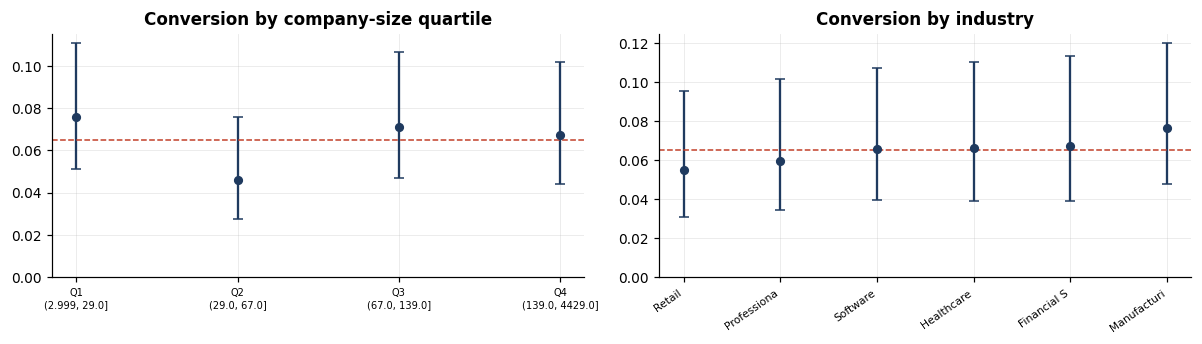

employee_count: Mann-Whitney p = 0.888


industry:       chi-square    p = 0.971


In [33]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
q = pd.qcut(train.employee_count, 4)
g = train.groupby(q, observed=True)[TARGET].agg(n="size", conversions="sum", rate="mean")
err = np.array([[r.rate - wilson(r.conversions, r.n)[0], wilson(r.conversions, r.n)[1] - r.rate]
                for _, r in g.iterrows()]).T
ax[0].errorbar(range(4), g.rate, yerr=err, fmt="o", color=INK, ms=5, capsize=3)
ax[0].axhline(BASE, color=WARN, ls="--", lw=1)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([f"Q{i+1}\n{iv}" for i, iv in enumerate(g.index)], fontsize=6.5)
ax[0].set_ylim(bottom=0); ax[0].set_title("Conversion by company-size quartile")

gi = train.groupby("industry")[TARGET].agg(n="size", conversions="sum", rate="mean").sort_values("rate")
err = np.array([[r.rate - wilson(r.conversions, r.n)[0], wilson(r.conversions, r.n)[1] - r.rate]
                for _, r in gi.iterrows()]).T
ax[1].errorbar(range(len(gi)), gi.rate, yerr=err, fmt="o", color=INK, ms=5, capsize=3)
ax[1].axhline(BASE, color=WARN, ls="--", lw=1)
ax[1].set_xticks(range(len(gi))); ax[1].set_xticklabels([i[:11] for i in gi.index], rotation=35, ha="right", fontsize=7)
ax[1].set_ylim(bottom=0); ax[1].set_title("Conversion by industry")
plt.tight_layout(); plt.show()
print(f"employee_count: Mann-Whitney p = {st.mannwhitneyu(train.loc[y==1,'employee_count'], train.loc[y==0,'employee_count']).pvalue:.3f}")
print(f"industry:       chi-square    p = {st.chi2_contingency(pd.crosstab(train.industry, y))[1]:.3f}")

Every firmographic interval crosses the base rate. Industry spreads from 5.8% to 8.8% and
χ² returns p = 0.97 — there is no industry effect here at all. Company size is flat
(p = 0.89). §5 shows why that matters: the model *does* allocate very differently across
these groups, on the basis of nothing measurable.

### 3.10 Censored labels

A label of "did not convert within 90 days" is only meaningful if 90 days have passed.

In [34]:
train["age_days"] = (TODAY - train.snapshot_date).dt.days
cens = train.age_days < 90
print(f"rows with less than 90 days of observation : {cens.sum()}")
print(f"of those, labeled 0                        : {(train.loc[cens, TARGET] == 0).sum()}  (all of them)")
print(f"share of all labels that cannot be correct : {cens.mean():.1%}")
print(f"note: the boundary matters -- 2026-08-01 minus 90 days is 2026-05-03, and a snapshot dated")
print(f"      exactly 2026-05-03 has a full window. Using '>= 2026-05-03' instead of age<90 gives "
      f"{(train.snapshot_date >= '2026-05-03').sum()} rows, not {cens.sum()}.\n")

qtr = train.snapshot_date.dt.to_period("Q")
show(train.groupby(qtr).agg(n=(TARGET, "size"), conversions=(TARGET, "sum"), rate=(TARGET, "mean")),
     "Conversion by snapshot quarter — the artifact is visible")

# do the censored rows differ from the rest?
rows = []
for f in NUM:
    a, b = train.loc[cens, f].dropna(), train.loc[~cens, f].dropna()
    rows.append({"feature": f, "censored mean": a.mean(), "rest mean": b.mean(),
                 "Mann-Whitney p": st.mannwhitneyu(a, b).pvalue})
d = pd.DataFrame(rows); d["p_BH"] = bh(d["Mann-Whitney p"])
show(d.sort_values("Mann-Whitney p"), "Are the censored rows a random slice?")

rows with less than 90 days of observation : 101
of those, labeled 0                        : 101  (all of them)
share of all labels that cannot be correct : 8.4%
note: the boundary matters -- 2026-08-01 minus 90 days is 2026-05-03, and a snapshot dated
      exactly 2026-05-03 has a full window. Using '>= 2026-05-03' instead of age<90 gives 103 rows, not 101.


Conversion by snapshot quarter — the artifact is visible
--------------------------------------------------------
                 n  conversions   rate
snapshot_date                         
2024Q3           6            0 0.0000
2024Q4          50            2 0.0400
2025Q1         103            5 0.0485
2025Q2         156           12 0.0769
2025Q3         226           18 0.0796
2025Q4         232           16 0.0690
2026Q1         264           20 0.0758
2026Q2         157            5 0.0318
2026Q3           6            0 0.0000

Are the censored rows a random slice?
-------------------------------------
               

In [35]:
clean = ~cens
auc_clean_pickle = roc_auc_score(y[clean], p_pickle[clean])
oof_clean = np.array([roc_auc_score(y[clean], p[clean]) for p in oof_all])
Xc, yc = X[clean].reset_index(drop=True), y[clean]
oof_refit = []
for rep in range(10):
    o = np.zeros(len(yc))
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=rep).split(Xc, yc):
        o[te] = clone(model).fit(Xc.iloc[tr], yc[tr]).predict_proba(Xc.iloc[te])[:, 1]
    oof_refit.append(roc_auc_score(yc, o))

show(pd.DataFrame({
    "value": [BASE, yc.mean(), IN["AUC"], auc_clean_pickle, OOF["AUC"], np.mean(oof_refit)]},
    index=["base rate, all 1200 rows", "base rate, censored rows dropped",
           "in-sample AUC, all rows", "in-sample AUC, censored rows dropped",
           "out-of-fold AUC, all rows", "out-of-fold AUC, refit without censored rows"]),
    "Does removing the bad labels help?")


Does removing the bad labels help?
----------------------------------
                                              value
base rate, all 1200 rows                     0.0650
base rate, censored rows dropped             0.0710
in-sample AUC, all rows                      0.7590
in-sample AUC, censored rows dropped         0.7563
out-of-fold AUC, all rows                    0.5731
out-of-fold AUC, refit without censored rows 0.5754


**101 labels — 8.4% of the training target — record "did not convert in 90 days" for
accounts that have not had 90 days.** The 2026Q2 row shows the artifact directly: 3.2%
conversion against 7–8% in every earlier quarter, and 2026Q3 is 0% of six rows.

And they are **not** a random slice: the censored accounts carry **33% more MQLs**
(p = 0.004, surviving BH correction) than the rest, while being recorded as failures. So
the contamination is mildly adversarial — it teaches the model that marketing-engaged
accounts don't convert.

**But fixing it does not rescue the model.** Drop all 101 rows and refit, and out-of-fold
AUC goes from 0.573 to **0.575** — a change of two thousandths, well inside the ±0.024
spread across splits. In-sample it barely moves either (0.759 → 0.756).

This is the point where a normal audit would have stopped: *"we found the bug — clean the
labels and retrain."* It would have been wrong. The gap between 0.759 and 0.573 is
overfitting, and no amount of label repair touches it. Censoring is a real defect in the
data pipeline and should be fixed on its own merits, but it is not why this model doesn't
work, and presenting it as the cause would send a team off to fix the wrong thing for a
quarter.

### 3.11 Freshness, and a drift claim that does not survive inspection

In [36]:
score["age_days"] = (TODAY - score.snapshot_date).dt.days
print(f"training snapshot age : median {train.age_days.median():.0f}d   range {train.age_days.min()}-{train.age_days.max()}d")
print(f"scoring  snapshot age : median {score.age_days.median():.0f}d   range {score.age_days.min()}-{score.age_days.max()}d\n")

def psi(a, b, bins=10):
    edges = np.unique(np.quantile(a, np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf
    pa = np.histogram(a, edges)[0] / len(a); pb = np.histogram(b, edges)[0] / len(b)
    pa, pb = np.clip(pa, 1e-6, None), np.clip(pb, 1e-6, None)
    return float(((pb - pa) * np.log(pb / pa)).sum())

rows = [{"variable": f, "PSI": psi(train[f].dropna(), score[f].dropna())} for f in NUM]
rows.append({"variable": "** snapshot_age **", "PSI": psi(train.age_days, score.age_days)})
d = pd.DataFrame(rows).sort_values("PSI", ascending=False)
d["reading"] = np.where(d.PSI > .25, "SEVERE", np.where(d.PSI > .1, "moderate", "stable"))
show(d, "Population Stability Index, training vs scoring")
print(f"\nPSI of snapshot age across binning schemes (5..20 bins): "
      f"{min(psi(train.age_days, score.age_days, b) for b in range(5,21)):.3f} – "
      f"{max(psi(train.age_days, score.age_days, b) for b in range(5,21)):.3f}   -> quote it as ~0.9, not 0.893")

for thr in (90, 180, 365):
    print(f"scoring accounts with a snapshot older than {thr:3d} days: {(score.age_days > thr).sum():3d} / 300")

training snapshot age : median 280d   range 1-711d
scoring  snapshot age : median 121d   range 0-675d


Population Stability Index, training vs scoring
-----------------------------------------------
              variable    PSI reading
7   ** snapshot_age ** 0.9064  SEVERE
1         intent_score 0.0575  stable
0       employee_count 0.0422  stable
5  web_touchpoints_90d 0.0313  stable
2        mql_count_90d 0.0228  stable
6   sales_contacts_90d 0.0127  stable
4   trial_active_users 0.0047  stable
3        trial_started 0.0000  stable

PSI of snapshot age across binning schemes (5..20 bins): 0.813 – 1.048   -> quote it as ~0.9, not 0.893
scoring accounts with a snapshot older than  90 days: 218 / 300
scoring accounts with a snapshot older than 180 days: 102 / 300
scoring accounts with a snapshot older than 365 days:  42 / 300


Every *feature* is stable between the two files (PSI well under 0.1). The only thing that
moved is **how old the snapshots are** — PSI ≈ 0.9, which any monitoring dashboard would
flag as severe drift.

**It is not drift.** §0.2 showed the two files are one population of 1500 split
non-randomly by recency: a fresh row had a 44% chance of landing in the scoring file, an
old one 10%. The scoring batch was *drawn* recency-biased. Reporting this as "the
population has shifted" would be a claim the panel can disprove by opening the CSVs, and
it would send someone to investigate a market change that never happened.

What remains true regardless is the operational point: **102 of the 300 accounts to be
scored carry information more than 180 days old**, and 42 are over a year old, while every
feature is a 90-day window. A rep calling those accounts is acting on a description of a
company that has since had two or three quarters to change.

One honesty note on that threshold: 180 days is my choice, not the brief's. The
window-consistent threshold is 90 days, and under it **218 of 300** accounts are stale.
I use 180 as the conservative line and flag the 90-day figure so the reader can pick.

---
### Section 3 verdict — where the signal actually is

| column | what the model thinks | what the data says |
|---|---|---|
| `intent_score` | most important, 0.271 | values worth **nothing** (Δ −0.001); only the *gap* predicts |
| `web_touchpoints_90d` | 2nd, 0.214 | p = 0.62. Importance is cardinality. |
| `sales_contacts_90d` | 3rd, 0.209 | **the only credible signal** (p = 0.0075) — and it's our own behaviour |
| `employee_count` | 4th, 0.111 | p = 0.89 |
| `trial_started` | 0.062 | plausible, p = 0.024, dies under correction |
| `trial_active_users` | 0.048 | n = 66 in the interesting cell |
| `mql_count_90d` | 0.044 | no ordering, χ² p = 0.37 |
| `industry` | 0.027 | χ² p = 0.97 |
| `account_type` | 0.013 | field is stale; 85% of "Suspects" are engaged |

> ### The structural finding
>
> The only two variables with a real claim to signal are `sales_contacts_90d` and
> `intent_known`. **Both of them measure what Cordilla — or the market — already did to
> the account, not what the account is.** The vendor returns a record for companies that
> already left a visible footprint; reps called the accounts that already looked
> promising.
>
> Remove both and the model scores **below chance**.
>
> So the conclusion is not "this model is contaminated by one circular feature." It is
> that **these nine columns contain no account-intrinsic signal at all.** Everything the
> model knows is a reflection of decisions Cordilla already made.

That changes what the recommendation has to be. "Fix the imputation and retrain" would
produce another model that reranks the accounts we already worked. The gap is not in the
algorithm, it is in **what is being measured** — and no model can close it.